In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

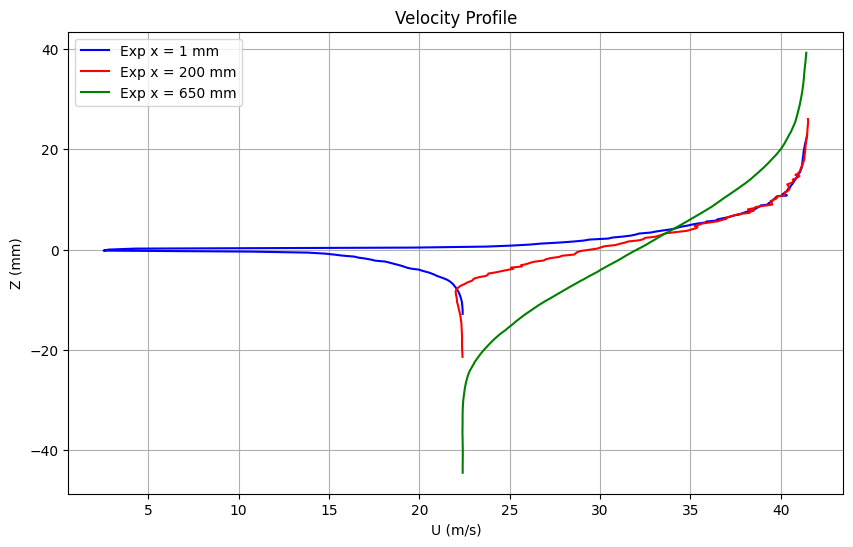

Index(['X(mm)_x1', 'Y(mm)_x1', 'U(m/s)_x1', 'Y/deltaw_x1', '(U-U1)/DeltaU_x1',
       'X(mm)_x50', 'Y(mm)_x50', 'U(m/s)_x50', 'Y/deltaw_x50',
       '(U-U1)/DeltaU_x50', 'X(mm)_x200', 'Y(mm)_x200', 'U(m/s)_x200',
       'Y/deltaw_x200', '(U-U1)/DeltaU_x200', 'X(mm)_x650', 'Y(mm)_x650',
       'U(m/s)_x650', 'Y/deltaw_x650', '(U-U1)/DeltaU_x650', 'X(mm)_x950',
       'Y(mm)_x950', 'U(m/s)_x950', 'Y/deltaw_x950', '(U-U1)/DeltaU_x950'],
      dtype='object')

In [6]:
import pandas as pd
import re

def read_txt_file(file_path):
    # Read the file
    with open(file_path, "r") as f:
        lines = f.readlines()

    # Get the variable names
    variables = []
    dataframes = []
    current_zone = None
    data_block = []

    for line in lines:
        # Get variable names
        if "VARIABLES" in line:
            # Clean up the line to get variable names
            variables = [v.strip().strip('"') for v in line.split("=")[1].split(",")]

        # Detect new ZONE
        elif line.strip().startswith("ZONE"):
            if data_block:
                # Save previous data block
                df = pd.DataFrame(data_block, columns=[f"{v}_{current_zone}" for v in variables])
                dataframes.append(df)
                data_block = []

            # Extract zone identifier
            match = re.search(r'x\s*=\s*(\d+)', line)
            if match:
                current_zone = f"x{match.group(1)}"

        # Parse data lines
        elif re.match(r"^[\d\.\-\+E]+", line.strip()):
            nums = list(map(float, line.strip().split()))
            data_block.append(nums)

    # Don't forget the last block
    if data_block:
        df = pd.DataFrame(data_block, columns=[f"{v}_{current_zone}" for v in variables])
        dataframes.append(df)

    # Combine all zone-specific data horizontally
    final_df = pd.concat(dataframes, axis=1)

    # Optionally save or inspect
    # final_df.to_csv("jet_data_combined.csv", index=False)
    return final_df

file = r'C:\Users\Korisnik\Documents\SARENA\LUT - SARENA M1S2\Turbulence Models\exercise10\experimental_data_1.txt'
file2 = r'C:\Users\Korisnik\Documents\SARENA\LUT - SARENA M1S2\Turbulence Models\exercise10\experimental_data_2_reynolds_stress.txt'

df_nasa1 = read_txt_file(file)
#df_nasa_axis2 = read_txt_file(file2)
df_nasa1.columns

plt.figure(figsize=(10, 6))
plt.plot(df_nasa1['U(m/s)_x1'], df_nasa1['Y(mm)_x1'],  label=r'Exp x = 1 mm', color='blue')
plt.plot(df_nasa1['U(m/s)_x200'], df_nasa1['Y(mm)_x200'],  label=r'Exp x = 200 mm', color='red')
plt.plot(df_nasa1['U(m/s)_x650'], df_nasa1['Y(mm)_x650'],  label=r'Exp x = 650 mm', color='green')

plt.xlabel('U (m/s)')
plt.title('Velocity Profile')
plt.ylabel('Z (mm)')
plt.legend()
plt.grid()
plt.show()
df_nasa1.columns


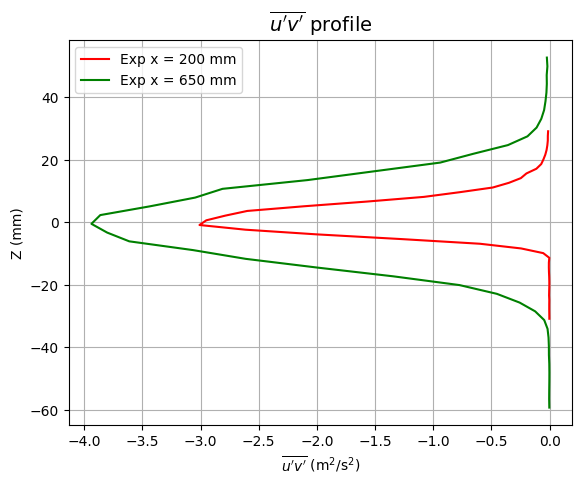

Index(['X(mm)_x200', 'Y(mm)_x200', 'y/deltaw_x200', 'u'v'(m**2/s**2)_x200',
       'u'v'/(deltaU)**2_x200', 'u'u'(m**2/s**2)_x200',
       'u'u'/(deltaU)**2_x200', 'v'v'(m**2/s**2)_x200',
       'v'v'/(deltaU)**2_x200', 'w'w'(m**2/s**2)_x200',
       'w'w'/(deltaU)**2_x200', 'X(mm)_x650', 'Y(mm)_x650', 'y/deltaw_x650',
       'u'v'(m**2/s**2)_x650', 'u'v'/(deltaU)**2_x650', 'u'u'(m**2/s**2)_x650',
       'u'u'/(deltaU)**2_x650', 'v'v'(m**2/s**2)_x650',
       'v'v'/(deltaU)**2_x650', 'w'w'(m**2/s**2)_x650',
       'w'w'/(deltaU)**2_x650', 'X(mm)_x950', 'Y(mm)_x950', 'y/deltaw_x950',
       'u'v'(m**2/s**2)_x950', 'u'v'/(deltaU)**2_x950', 'u'u'(m**2/s**2)_x950',
       'u'u'/(deltaU)**2_x950', 'v'v'(m**2/s**2)_x950',
       'v'v'/(deltaU)**2_x950', 'w'w'(m**2/s**2)_x950',
       'w'w'/(deltaU)**2_x950'],
      dtype='object')

In [7]:
from typing import final
import pandas as pd
import re

def read_txt_file(file_path):
    # Read the file
    with open(file_path, "r") as f:
        lines = f.readlines()

    # Get the variable names
    variables = []
    dataframes = []
    current_zone = None
    data_block = []

    for line in lines:
        # Get variable names
        if "VARIABLES" in line:
            # Clean up the line to get variable names
            variables = [v.strip().strip('"') for v in line.split("=")[1].split(",")]

        # Detect new ZONE
        elif line.strip().startswith("ZONE"):
            if data_block:
                # Save previous data block
                df = pd.DataFrame(data_block, columns=[f"{v}_{current_zone}" for v in variables])
                dataframes.append(df)
                data_block = []

            # Extract zone identifier
            match = re.search(r'x\s*=\s*(\d+)', line)
            if match:
                current_zone = f"x{match.group(1)}"

        # Parse data lines
        elif re.match(r"^[\d\.\-\+E]+", line.strip()):
            nums = list(map(float, line.strip().split()))
            data_block.append(nums)

    # Don't forget the last block
    if data_block:
        df = pd.DataFrame(data_block, columns=[f"{v}_{current_zone}" for v in variables])
        dataframes.append(df)

    # Combine all zone-specific data horizontally
    final_df = pd.concat(dataframes, axis=1)

    # Optionally save or inspect
    # final_df.to_csv("jet_data_combined.csv", index=False)
    return final_df


file2 = r'C:\Users\Korisnik\Documents\SARENA\LUT - SARENA M1S2\Turbulence Models\exercise10\experimental_data_2_reynolds_stress.txt'

df_nasa_axis2 = read_txt_file(file2)

plt.figure(figsize=(6.5, 5))

plt.plot( df_nasa_axis2["u'v'(m**2/s**2)_x200"],  df_nasa_axis2['Y(mm)_x200'], label=r'Exp x = 200 mm', color='red')
plt.plot(df_nasa_axis2["u'v'(m**2/s**2)_x650"],df_nasa_axis2['Y(mm)_x650'],   label=r'Exp x = 650 mm', color='green')

plt.xlabel(r"$\overline{u'v'}$ (m$^2$/s$^2$)")
plt.ylabel('Z (mm)')
plt.title(r"$\overline{u'v'}$ profile", fontsize=14)

plt.legend()
plt.grid()
plt.show()

df_nasa_axis2.columns

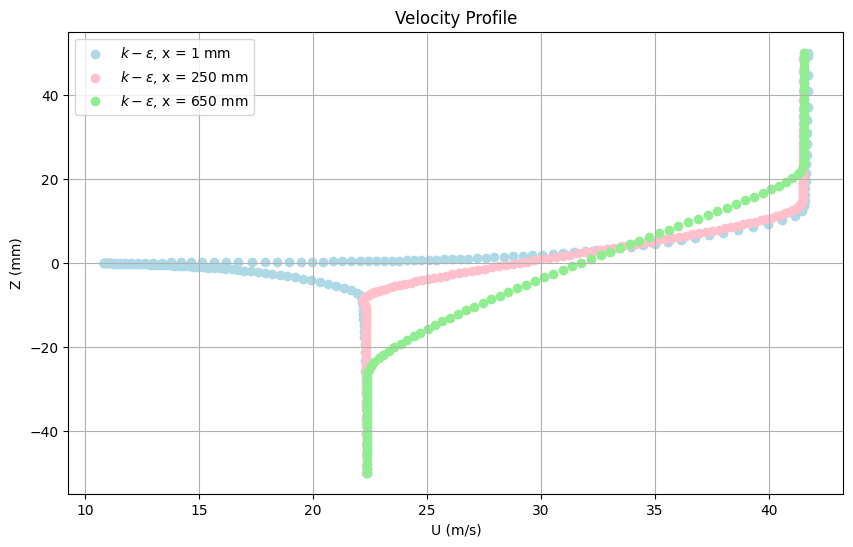

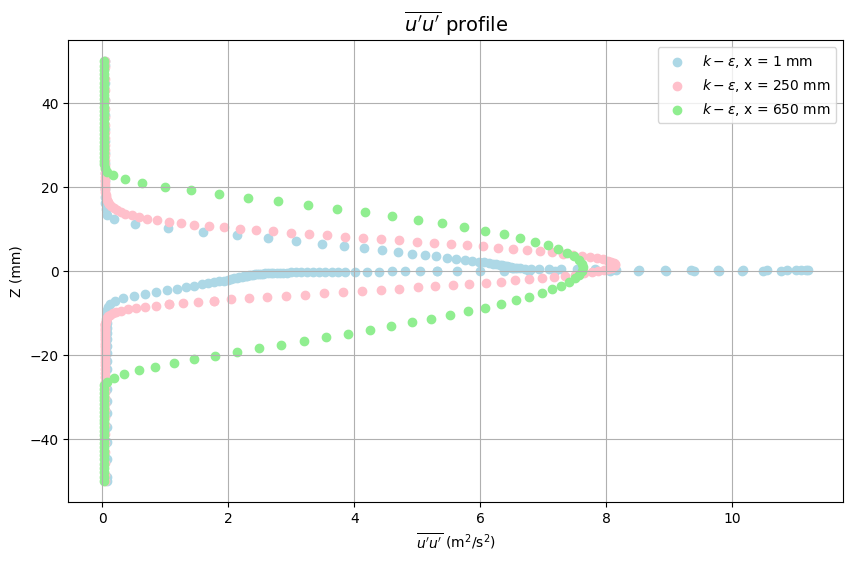

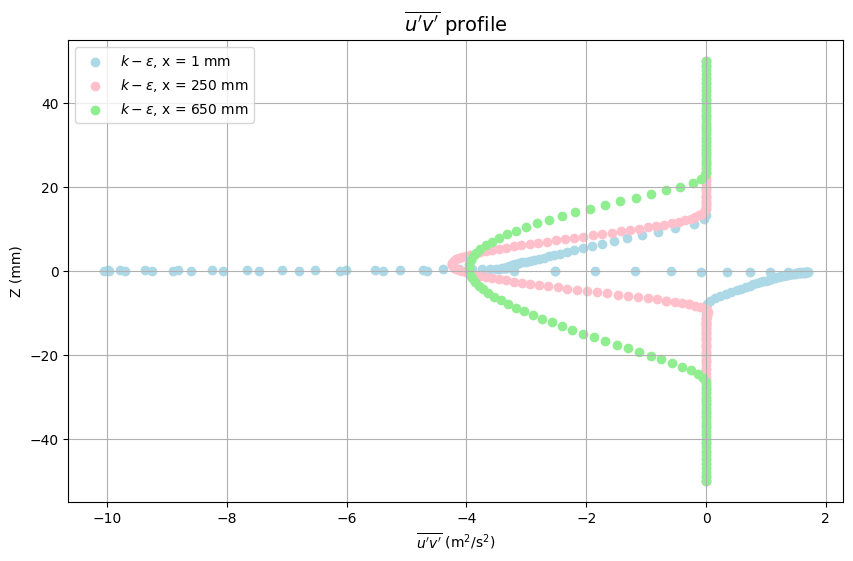

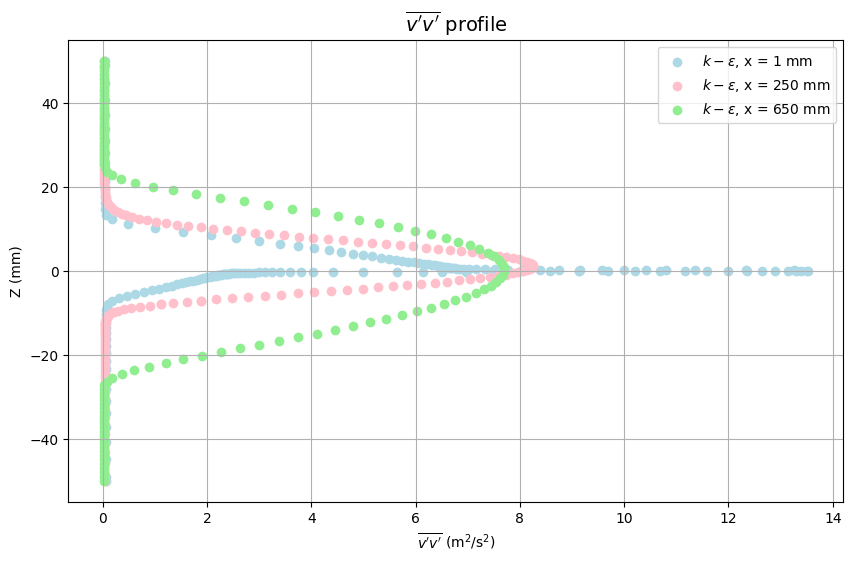

,ke-uu-uu_x=1mm,ke-uu-Z-Coordinate_x=1mm,ke-uu-uu_x=200,ke-uu-Z-Coordinate_x=200,ke-uu-uu_x=650mm,ke-uu-Z-Coordinate_x=650mm,ke-uv-uv_x=1mm,ke-uv-Z-Coordinate_x=1mm,ke-uv-uv_x=200,ke-uv-Z-Coordinate_x=200,...,ke-vv-vv_x=200,ke-vv-Z-Coordinate_x=200,ke-vv-vv_x=650mm,ke-vv-Z-Coordinate_x=650mm,ke-vel-Velocity Magnitude_x=1mm,ke-vel-Z-Coordinate_x=1mm,ke-vel-Velocity Magnitude_x=200,ke-vel-Z-Coordinate_x=200,ke-vel-Velocity Magnitude_x=650mm,ke-vel-Z-Coordinate_x=650mm
0,0.066181,-5.000000e-02,0.036801,-0.050000,0.019066,0.050000,0.000225,-5.000000e-02,8.183930e-07,-0.050000,...,0.036842,-0.050000,0.019075,0.050000,22.3553,-5.000000e-02,22.3351,-0.050000,41.5393,0.050000
1,0.066192,-4.911060e-02,0.036803,-0.048484,0.019065,0.048943,0.000235,-4.911060e-02,6.714160e-07,-0.048484,...,0.036843,-0.048484,0.019074,0.048943,22.3543,-4.911060e-02,22.3351,-0.048484,41.5393,0.048943
2,0.066253,-4.475600e-02,0.036805,-0.045717,0.019064,0.047898,0.000293,-4.475600e-02,3.616120e-07,-0.045717,...,0.036846,-0.045717,0.019072,0.047898,22.3479,-4.475600e-02,22.3351,-0.045717,41.5393,0.047898
3,0.066318,-4.078930e-02,0.036807,-0.043173,0.019062,0.046869,0.000357,-4.078930e-02,7.660340e-08,-0.043173,...,0.036848,-0.043173,0.019071,0.046869,22.3408,-4.078930e-02,22.3351,-0.043173,41.5393,0.046869
4,0.066386,-3.717600e-02,0.036809,-0.040832,0.019061,0.045854,0.000430,-3.717600e-02,-1.996070e-07,-0.040832,...,0.036851,-0.040832,0.019070,0.045854,22.3329,-3.717600e-02,22.3351,-0.040832,41.5393,0.045854
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,6.770830,-3.056320e-18,NaN,NaN,NaN,NaN,-5.390730,-3.056320e-18,NaN,NaN,...,NaN,NaN,NaN,NaN,12.0071,-3.056320e-18,NaN,NaN,NaN,NaN
160,6.368340,-1.228280e-05,NaN,NaN,NaN,NaN,-4.661490,-1.228280e-05,NaN,NaN,...,NaN,NaN,NaN,NaN,11.7434,-1.228280e-05,NaN,NaN,NaN,NaN
161,5.987570,-2.462110e-05,NaN,NaN,NaN,NaN,-3.930310,-2.462110e-05,NaN,NaN,...,NaN,NaN,NaN,NaN,11.5104,-2.462110e-05,NaN,NaN,NaN,NaN
162,5.633310,-3.707160e-05,NaN,NaN,NaN,NaN,-3.210690,-3.707160e-05,NaN,NaN,...,NaN,NaN,NaN,NaN,11.3091,-3.707160e-05,NaN,NaN,NaN,NaN


In [8]:
import pandas as pd
import re

with open("exercise10/ke-standard-z-over-uu.xy", "r") as f:
    content = f.read()

# Extract labels
labels_match = re.search(r'\(labels\s+"([^"]+)"\s+"([^"]+)"\)', content)
if labels_match:
    label1, label2 = labels_match.groups()
else:
    raise ValueError("Could not find labels.")

# Extract each data block with its key/label
blocks = re.findall(
    r'\(xy/key/label\s+"([^"]+)"\)\s*((?:-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s+-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s*\n?)+)',
    content
)

dfs = []
for key, data_block in blocks:
    # Convert string block to list of [x, y]
    data = [
        list(map(float, line.strip().split()))
        for line in data_block.strip().splitlines()
        if line.strip()
    ]
    df = pd.DataFrame(data, columns=[f"ke-uu-{label1}_{key}", f"ke-uu-{label2}_{key}"])
    dfs.append(df)



# Combine into one dataframe, aligning rows
ke_uu = pd.concat(dfs, axis=1)

# Show or save
ke_uu

import pandas as pd
import re

with open("exercise10/ke-standard-z-over-uv.xy", "r") as f:
    content = f.read()

# Extract labels
labels_match = re.search(r'\(labels\s+"([^"]+)"\s+"([^"]+)"\)', content)
if labels_match:
    label1, label2 = labels_match.groups()
else:
    raise ValueError("Could not find labels.")

# Extract each data block with its key/label
blocks = re.findall(
    r'\(xy/key/label\s+"([^"]+)"\)\s*((?:-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s+-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s*\n?)+)',
    content
)

dfs = []
for key, data_block in blocks:
    # Convert string block to list of [x, y]
    data = [
        list(map(float, line.strip().split()))
        for line in data_block.strip().splitlines()
        if line.strip()
    ]
    df = pd.DataFrame(data, columns=[f"ke-uv-{label1}_{key}", f"ke-uv-{label2}_{key}"])
    dfs.append(df)


ke_uv = pd.concat(dfs, axis=1)
ke_uv

import pandas as pd
import re

with open("exercise10/ke-standard-z-over-vv.xy", "r") as f:
    content = f.read()

# Extract labels
labels_match = re.search(r'\(labels\s+"([^"]+)"\s+"([^"]+)"\)', content)
if labels_match:
    label1, label2 = labels_match.groups()
else:
    raise ValueError("Could not find labels.")

# Extract each data block with its key/label
blocks = re.findall(
    r'\(xy/key/label\s+"([^"]+)"\)\s*((?:-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s+-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s*\n?)+)',
    content
)

dfs = []
for key, data_block in blocks:
    # Convert string block to list of [x, y]
    data = [
        list(map(float, line.strip().split()))
        for line in data_block.strip().splitlines()
        if line.strip()
    ]
    df = pd.DataFrame(data, columns=[f"ke-vv-{label1}_{key}", f"ke-vv-{label2}_{key}"])
    dfs.append(df)


ke_vv = pd.concat(dfs, axis=1)
ke_vv.columns

with open("exercise10/ke-standard-z-over-velocity-magnitude.xy", "r") as f:
    content = f.read()

# Extract labels
labels_match = re.search(r'\(labels\s+"([^"]+)"\s+"([^"]+)"\)', content)
if labels_match:
    label1, label2 = labels_match.groups()
else:
    raise ValueError("Could not find labels.")

# Extract each data block with its key/label
blocks = re.findall(
    r'\(xy/key/label\s+"([^"]+)"\)\s*((?:-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s+-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s*\n?)+)',
    content
)

dfs = []
for key, data_block in blocks:
    # Convert string block to list of [x, y]
    data = [
        list(map(float, line.strip().split()))
        for line in data_block.strip().splitlines()
        if line.strip()
    ]
    df = pd.DataFrame(data, columns=[f"ke-vel-{label1}_{key}", f"ke-vel-{label2}_{key}"])
    dfs.append(df)


ke_u = pd.concat(dfs, axis=1)

ke = pd.concat([ke_uu, ke_uv, ke_vv, ke_u], axis=1)
ke.columns

plt.figure(figsize=(10, 6))
plt.scatter(ke['ke-vel-Velocity Magnitude_x=1mm'], ke['ke-vel-Z-Coordinate_x=1mm']*1000,  label=r'$k-\varepsilon$, x = 1 mm', color='lightblue')
plt.scatter(ke['ke-vel-Velocity Magnitude_x=200'], ke['ke-vel-Z-Coordinate_x=200']*1000,  label=r'$k-\varepsilon$, x = 250 mm', color='pink')
plt.scatter(ke['ke-vel-Velocity Magnitude_x=650mm'], ke['ke-vel-Z-Coordinate_x=650mm']*1000,  label=r'$k-\varepsilon$, x = 650 mm', color='lightgreen')

plt.xlabel('U (m/s)')
plt.title('Velocity Profile')
plt.ylabel('Z (mm)')    
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(ke['ke-uu-uu_x=1mm'], ke['ke-uu-Z-Coordinate_x=1mm']*1000,  label=r'$k-\varepsilon$, x = 1 mm', color='lightblue')
plt.scatter(ke['ke-uu-uu_x=200'], ke['ke-uu-Z-Coordinate_x=200']*1000,  label=r'$k-\varepsilon$, x = 250 mm', color='pink')
plt.scatter(ke['ke-uu-uu_x=650mm'], ke['ke-uu-Z-Coordinate_x=650mm']*1000,  label=r'$k-\varepsilon$, x = 650 mm', color='lightgreen')
plt.xlabel(r"$\overline{u'u'}$ (m$^2$/s$^2$)")
plt.ylabel('Z (mm)')        
plt.title(r"$\overline{u'u'}$ profile", fontsize=14)
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(ke['ke-uv-uv_x=1mm'], ke['ke-uv-Z-Coordinate_x=1mm']*1000,  label=r'$k-\varepsilon$, x = 1 mm', color='lightblue')
plt.scatter(ke['ke-uv-uv_x=200'], ke['ke-uv-Z-Coordinate_x=200']*1000,  label=r'$k-\varepsilon$, x = 250 mm', color='pink')
plt.scatter(ke['ke-uv-uv_x=650mm'], ke['ke-uv-Z-Coordinate_x=650mm']*1000,  label=r'$k-\varepsilon$, x = 650 mm', color='lightgreen')
plt.xlabel(r"$\overline{u'v'}$ (m$^2$/s$^2$)")
plt.ylabel('Z (mm)')        
plt.title(r"$\overline{u'v'}$ profile", fontsize=14)
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(ke['ke-vv-vv_x=1mm'], ke['ke-vv-Z-Coordinate_x=1mm']*1000,  label=r'$k-\varepsilon$, x = 1 mm', color='lightblue')
plt.scatter(ke['ke-vv-vv_x=200'], ke['ke-vv-Z-Coordinate_x=200']*1000,  label=r'$k-\varepsilon$, x = 250 mm', color='pink')
plt.scatter(ke['ke-vv-vv_x=650mm'], ke['ke-vv-Z-Coordinate_x=650mm']*1000,  label=r'$k-\varepsilon$, x = 650 mm', color='lightgreen')
plt.xlabel(r"$\overline{v'v'}$ (m$^2$/s$^2$)")
plt.ylabel('Z (mm)')        
plt.title(r"$\overline{v'v'}$ profile", fontsize=14)
plt.legend()
plt.grid()
plt.show()


ke

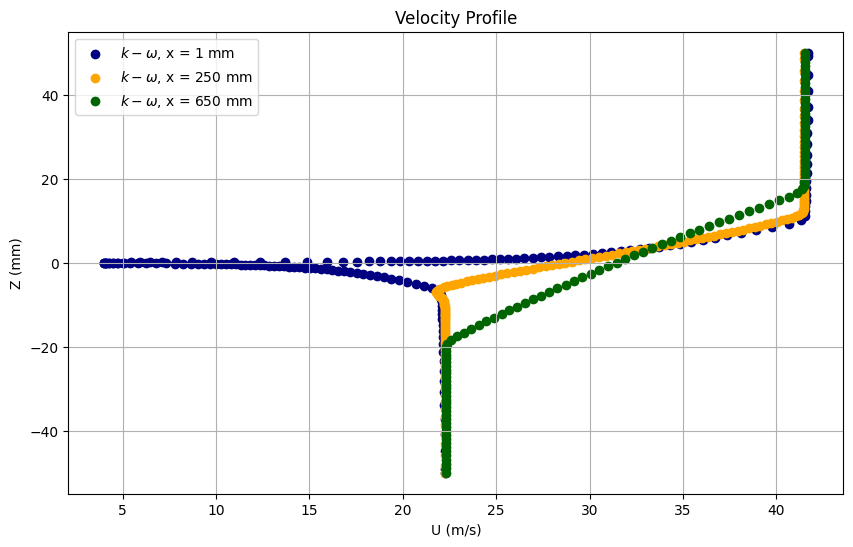

,ko-uu-uu_x=1mm,ko-uu-Z-Coordinate_x=1mm,ko-uu-uu_x=200,ko-uu-Z-Coordinate_x=200,ko-uu-uu_x=650mm,ko-uu-Z-Coordinate_x=650mm,ko-uv-uv_x=1mm,ko-uv-Z-Coordinate_x=1mm,ko-uv-uv_x=200,ko-uv-Z-Coordinate_x=200,...,ko-vv-vv_x=200,ko-vv-Z-Coordinate_x=200,ko-vv-vv_x=650mm,ko-vv-Z-Coordinate_x=650mm,ko-vel-Velocity Magnitude_x=1mm,ko-vel-Z-Coordinate_x=1mm,ko-vel-Velocity Magnitude_x=200,ko-vel-Z-Coordinate_x=200,ko-vel-Velocity Magnitude_x=650mm,ko-vel-Z-Coordinate_x=650mm
0,0.050587,-5.000000e-02,0.027565,-0.050000,0.014627,0.050000,0.000196,-5.000000e-02,0.000003,-0.050000,...,0.027614,-0.050000,0.014645,0.050000,22.26120,-5.000000e-02,22.2418,-0.050000,41.5114,0.050000
1,0.050598,-4.911060e-02,0.027566,-0.048484,0.014627,0.048943,0.000205,-4.911060e-02,0.000003,-0.048484,...,0.027616,-0.048484,0.014645,0.048943,22.26020,-4.911060e-02,22.2417,-0.048484,41.5114,0.048943
2,0.050659,-4.475600e-02,0.027569,-0.045717,0.014628,0.047898,0.000255,-4.475600e-02,0.000003,-0.045717,...,0.027619,-0.045717,0.014646,0.047898,22.25400,-4.475600e-02,22.2417,-0.045717,41.5114,0.047898
3,0.050725,-4.078930e-02,0.027571,-0.043173,0.014628,0.046869,0.000310,-4.078930e-02,0.000003,-0.043173,...,0.027621,-0.043173,0.014646,0.046869,22.24710,-4.078930e-02,22.2416,-0.043173,41.5114,0.046869
4,0.050795,-3.717600e-02,0.027574,-0.040832,0.014629,0.045854,0.000373,-3.717600e-02,0.000003,-0.040832,...,0.027624,-0.040832,0.014647,0.045854,22.23950,-3.717600e-02,22.2415,-0.040832,41.5114,0.045854
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,1.006120,-3.056320e-18,NaN,NaN,NaN,NaN,-0.392251,-3.056320e-18,NaN,NaN,...,NaN,NaN,NaN,NaN,4.10558,-3.056320e-18,NaN,NaN,NaN,NaN
160,0.896081,-1.228280e-05,NaN,NaN,NaN,NaN,-0.184496,-1.228280e-05,NaN,NaN,...,NaN,NaN,NaN,NaN,4.01587,-1.228280e-05,NaN,NaN,NaN,NaN
161,0.827272,-2.462110e-05,NaN,NaN,NaN,NaN,0.005711,-2.462110e-05,NaN,NaN,...,NaN,NaN,NaN,NaN,3.98653,-2.462110e-05,NaN,NaN,NaN,NaN
162,0.795976,-3.707160e-05,NaN,NaN,NaN,NaN,0.177054,-3.707160e-05,NaN,NaN,...,NaN,NaN,NaN,NaN,4.01773,-3.707160e-05,NaN,NaN,NaN,NaN


In [9]:

import pandas as pd
import re

with open("exercise10/ko-standard-z-over-uu.xy", "r") as f:
    content = f.read()

# Extract labels
labels_match = re.search(r'\(labels\s+"([^"]+)"\s+"([^"]+)"\)', content)
if labels_match:
    label1, label2 = labels_match.groups()
else:
    raise ValueError("Could not find labels.")

# Extract each data block with its key/label
blocks = re.findall(
    r'\(xy/key/label\s+"([^"]+)"\)\s*((?:-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s+-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s*\n?)+)',
    content
)

dfs = []
for key, data_block in blocks:
    # Convert string block to list of [x, y]
    data = [
        list(map(float, line.strip().split()))
        for line in data_block.strip().splitlines()
        if line.strip()
    ]
    df = pd.DataFrame(data, columns=[f"ko-uu-{label1}_{key}", f"ko-uu-{label2}_{key}"])
    dfs.append(df)



# Combine into one dataframe, aligning rows
ko_uu = pd.concat(dfs, axis=1)



import pandas as pd
import re

with open("exercise10/ko-standard-z-over-uv.xy", "r") as f:
    content = f.read()

# Extract labels
labels_match = re.search(r'\(labels\s+"([^"]+)"\s+"([^"]+)"\)', content)
if labels_match:
    label1, label2 = labels_match.groups()
else:
    raise ValueError("Could not find labels.")

# Extract each data block with its key/label
blocks = re.findall(
    r'\(xy/key/label\s+"([^"]+)"\)\s*((?:-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s+-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s*\n?)+)',
    content
)

dfs = []
for key, data_block in blocks:
    # Convert string block to list of [x, y]
    data = [
        list(map(float, line.strip().split()))
        for line in data_block.strip().splitlines()
        if line.strip()
    ]
    df = pd.DataFrame(data, columns=[f"ko-uv-{label1}_{key}", f"ko-uv-{label2}_{key}"])
    dfs.append(df)


ko_uv = pd.concat(dfs, axis=1)
ko_uv

import pandas as pd
import re

with open("exercise10/ko-standard-z-over-vv.xy", "r") as f:
    content = f.read()

# Extract labels
labels_match = re.search(r'\(labels\s+"([^"]+)"\s+"([^"]+)"\)', content)
if labels_match:
    label1, label2 = labels_match.groups()
else:
    raise ValueError("Could not find labels.")

# Extract each data block with its key/label
blocks = re.findall(
    r'\(xy/key/label\s+"([^"]+)"\)\s*((?:-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s+-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s*\n?)+)',
    content
)

dfs = []
for key, data_block in blocks:
    # Convert string block to list of [x, y]
    data = [
        list(map(float, line.strip().split()))
        for line in data_block.strip().splitlines()
        if line.strip()
    ]
    df = pd.DataFrame(data, columns=[f"ko-vv-{label1}_{key}", f"ko-vv-{label2}_{key}"])
    dfs.append(df)


ko_vv = pd.concat(dfs, axis=1)



with open("exercise10/ko-standard-z-over-velocity-magnitude.xy", "r") as f:
    content = f.read()

# Extract labels
labels_match = re.search(r'\(labels\s+"([^"]+)"\s+"([^"]+)"\)', content)
if labels_match:
    label1, label2 = labels_match.groups()
else:
    raise ValueError("Could not find labels.")

# Extract each data block with its key/label
blocks = re.findall(
    r'\(xy/key/label\s+"([^"]+)"\)\s*((?:-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s+-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s*\n?)+)',
    content
)

dfs = []
for key, data_block in blocks:
    # Convert string block to list of [x, y]
    data = [
        list(map(float, line.strip().split()))
        for line in data_block.strip().splitlines()
        if line.strip()
    ]
    df = pd.DataFrame(data, columns=[f"ko-vel-{label1}_{key}", f"ko-vel-{label2}_{key}"])
    dfs.append(df)


ko_u = pd.concat(dfs, axis=1)

ko = pd.concat([ko_uu, ko_uv, ko_vv, ko_u], axis=1)

plt.figure(figsize=(10, 6))
plt.scatter(ko['ko-vel-Velocity Magnitude_x=1mm'], ko['ko-vel-Z-Coordinate_x=1mm']*1000,  label=r'$k-\omega$, x = 1 mm', color='navy')
plt.scatter(ko['ko-vel-Velocity Magnitude_x=200'], ko['ko-vel-Z-Coordinate_x=200']*1000,  label=r'$k-\omega$, x = 250 mm', color='orange')
plt.scatter(ko['ko-vel-Velocity Magnitude_x=650mm'], ko['ko-vel-Z-Coordinate_x=650mm']*1000,  label=r'$k-\omega$, x = 650 mm', color='darkgreen')

plt.xlabel('U (m/s)')
plt.title('Velocity Profile')
plt.ylabel('Z (mm)')    
plt.legend()
plt.grid()
plt.show()

ko



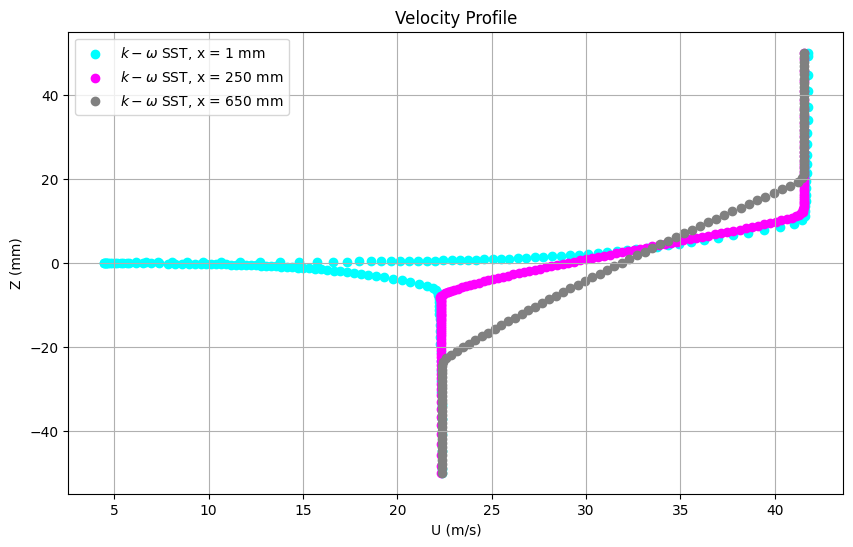

,ko-sst-uu-uu_x=1mm,ko-sst-uu-Z-Coordinate_x=1mm,ko-sst-uu-uu_x=200,ko-sst-uu-Z-Coordinate_x=200,ko-sst-uu-uu_x=650mm,ko-sst-uu-Z-Coordinate_x=650mm,ko-sst-vv-vv_x=1mm,ko-sst-vv-Z-Coordinate_x=1mm,ko-sst-vv-vv_x=200,ko-sst-vv-Z-Coordinate_x=200,...,ko-sst-uv-uv_x=200,ko-sst-uv-Z-Coordinate_x=200,ko-sst-uv-uv_x=650mm,ko-sst-uv-Z-Coordinate_x=650mm,ko-sst-vel-Velocity Magnitude_x=1mm,ko-sst-vel-Z-Coordinate_x=1mm,ko-sst-vel-Velocity Magnitude_x=200,ko-sst-vel-Z-Coordinate_x=200,ko-sst-vel-Velocity Magnitude_x=650mm,ko-sst-vel-Z-Coordinate_x=650mm
0,0.067216,-5.000000e-02,0.039373,-0.050000,0.026546,0.050000,0.065881,-5.000000e-02,0.039427,-0.050000,...,0.000003,-0.050000,-7.435950e-07,0.050000,22.36910,-5.000000e-02,22.3381,-0.050000,41.54,0.050000
1,0.067231,-4.911060e-02,0.039374,-0.048484,0.026547,0.048943,0.065870,-4.911060e-02,0.039428,-0.048484,...,0.000003,-0.048484,-7.460490e-07,0.048943,22.36810,-4.911060e-02,22.3380,-0.048484,41.54,0.048943
2,0.067318,-4.475600e-02,0.039375,-0.045717,0.026547,0.047898,0.065804,-4.475600e-02,0.039431,-0.045717,...,0.000002,-0.045717,-7.491850e-07,0.047898,22.36210,-4.475600e-02,22.3380,-0.045717,41.54,0.047898
3,0.067410,-4.078930e-02,0.039377,-0.043173,0.026548,0.046869,0.065733,-4.078930e-02,0.039433,-0.043173,...,0.000002,-0.043173,-7.540240e-07,0.046869,22.35540,-4.078930e-02,22.3380,-0.043173,41.54,0.046869
4,0.067510,-3.717600e-02,0.039379,-0.040832,0.026549,0.045854,0.065655,-3.717600e-02,0.039435,-0.040832,...,0.000001,-0.040832,-7.612770e-07,0.045854,22.34790,-3.717600e-02,22.3380,-0.040832,41.54,0.045854
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,2.566950,-3.056320e-18,NaN,NaN,NaN,NaN,4.270980,-3.056320e-18,NaN,NaN,...,NaN,NaN,NaN,NaN,4.61069,-3.056320e-18,NaN,NaN,NaN,NaN
160,2.322590,-1.228280e-05,NaN,NaN,NaN,NaN,3.833870,-1.228280e-05,NaN,NaN,...,NaN,NaN,NaN,NaN,4.49036,-1.228280e-05,NaN,NaN,NaN,NaN
161,2.112020,-2.462110e-05,NaN,NaN,NaN,NaN,3.441490,-2.462110e-05,NaN,NaN,...,NaN,NaN,NaN,NaN,4.43824,-2.462110e-05,NaN,NaN,NaN,NaN
162,1.936200,-3.707160e-05,NaN,NaN,NaN,NaN,3.102450,-3.707160e-05,NaN,NaN,...,NaN,NaN,NaN,NaN,4.45707,-3.707160e-05,NaN,NaN,NaN,NaN


In [10]:

import pandas as pd
import re

with open("exercise10/ko-sst-z-over-uu.xy", "r") as f:
    content = f.read()

# Extract labels
labels_match = re.search(r'\(labels\s+"([^"]+)"\s+"([^"]+)"\)', content)
if labels_match:
    label1, label2 = labels_match.groups()
else:
    raise ValueError("Could not find labels.")

# Extract each data block with its key/label
blocks = re.findall(
    r'\(xy/key/label\s+"([^"]+)"\)\s*((?:-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s+-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s*\n?)+)',
    content
)

dfs = []
for key, data_block in blocks:
    # Convert string block to list of [x, y]
    data = [
        list(map(float, line.strip().split()))
        for line in data_block.strip().splitlines()
        if line.strip()
    ]
    df = pd.DataFrame(data, columns=[f"ko-sst-uu-{label1}_{key}", f"ko-sst-uu-{label2}_{key}"])
    dfs.append(df)


# Combine into one dataframe, aligning rows
ko_sst_uu = pd.concat(dfs, axis=1)




with open("exercise10/ko-sst-z-over-uv.xy", "r") as f:
    content = f.read()

# Extract labels
labels_match = re.search(r'\(labels\s+"([^"]+)"\s+"([^"]+)"\)', content)
if labels_match:
    label1, label2 = labels_match.groups()
else:
    raise ValueError("Could not find labels.")

# Extract each data block with its key/label
blocks = re.findall(
    r'\(xy/key/label\s+"([^"]+)"\)\s*((?:-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s+-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s*\n?)+)',
    content
)

dfs = []
for key, data_block in blocks:
    # Convert string block to list of [x, y]
    data = [
        list(map(float, line.strip().split()))
        for line in data_block.strip().splitlines()
        if line.strip()
    ]
    df = pd.DataFrame(data, columns=[f"ko-sst-uv-{label1}_{key}", f"ko-sst-uv-{label2}_{key}"])
    dfs.append(df)


ko_sst_uv = pd.concat(dfs, axis=1)




with open("exercise10/ko-sst-z-over-vv.xy", "r") as f:
    content = f.read()

# Extract labels
labels_match = re.search(r'\(labels\s+"([^"]+)"\s+"([^"]+)"\)', content)
if labels_match:
    label1, label2 = labels_match.groups()
else:
    raise ValueError("Could not find labels.")

# Extract each data block with its key/label
blocks = re.findall(
    r'\(xy/key/label\s+"([^"]+)"\)\s*((?:-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s+-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s*\n?)+)',
    content
)

dfs = []
for key, data_block in blocks:
    # Convert string block to list of [x, y]
    data = [
        list(map(float, line.strip().split()))
        for line in data_block.strip().splitlines()
        if line.strip()
    ]
    df = pd.DataFrame(data, columns=[f"ko-sst-vv-{label1}_{key}", f"ko-sst-vv-{label2}_{key}"])
    dfs.append(df)


ko_sst_vv = pd.concat(dfs, axis=1)


with open("exercise10/ko-sst-z-over-velocity-magnitude.xy", "r") as f:
    content = f.read()

# Extract labels
labels_match = re.search(r'\(labels\s+"([^"]+)"\s+"([^"]+)"\)', content)
if labels_match:
    label1, label2 = labels_match.groups()
else:
    raise ValueError("Could not find labels.")

# Extract each data block with its key/label
blocks = re.findall(
    r'\(xy/key/label\s+"([^"]+)"\)\s*((?:-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s+-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s*\n?)+)',
    content
)

dfs = []
for key, data_block in blocks:
    # Convert string block to list of [x, y]
    data = [
        list(map(float, line.strip().split()))
        for line in data_block.strip().splitlines()
        if line.strip()
    ]
    df = pd.DataFrame(data, columns=[f"ko-sst-vel-{label1}_{key}", f"ko-sst-vel-{label2}_{key}"])
    dfs.append(df)


ko_sst_u = pd.concat(dfs, axis=1)

ko_sst = pd.concat([ko_sst_uu, ko_sst_vv, ko_sst_uv, ko_sst_u], axis=1)


plt.figure(figsize=(10, 6))
plt.scatter(ko_sst['ko-sst-vel-Velocity Magnitude_x=1mm'], ko_sst['ko-sst-vel-Z-Coordinate_x=1mm']*1000,  label=r'$k-\omega$ SST, x = 1 mm', color='cyan')
plt.scatter(ko_sst['ko-sst-vel-Velocity Magnitude_x=200'], ko_sst['ko-sst-vel-Z-Coordinate_x=200']*1000,  label=r'$k-\omega$ SST, x = 250 mm', color='magenta')
plt.scatter(ko_sst['ko-sst-vel-Velocity Magnitude_x=650mm'], ko_sst['ko-sst-vel-Z-Coordinate_x=650mm']*1000,  label=r'$k-\omega$ SST, x = 650 mm', color='grey')   

plt.xlabel('U (m/s)')
plt.title('Velocity Profile')   
plt.ylabel('Z (mm)')
plt.legend()
plt.grid()
plt.show()

ko_sst



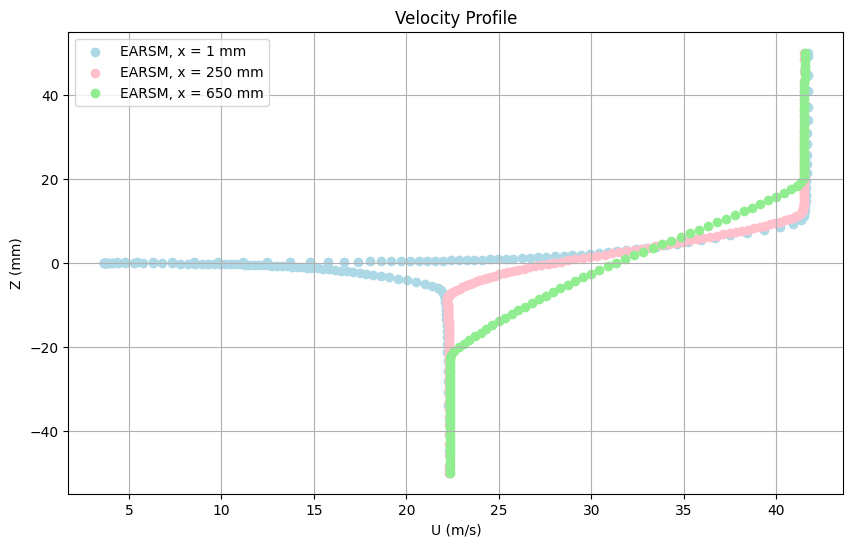

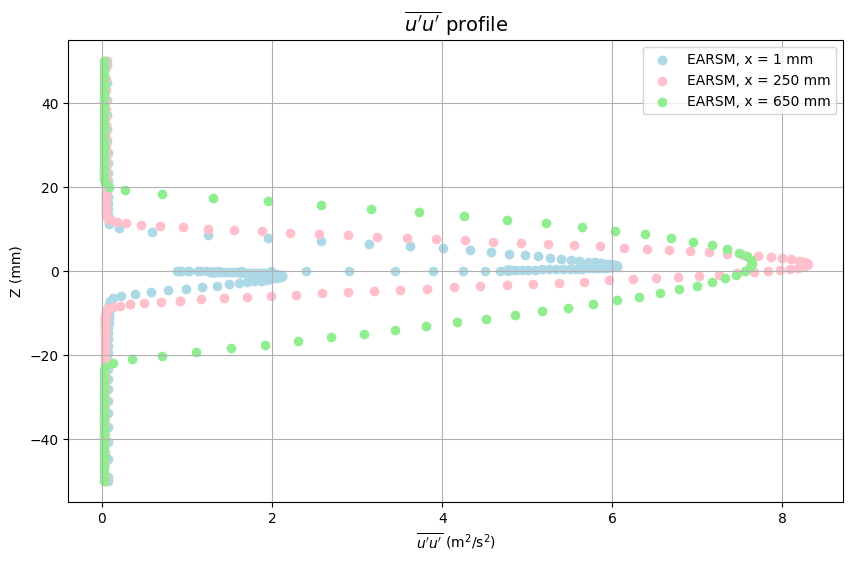

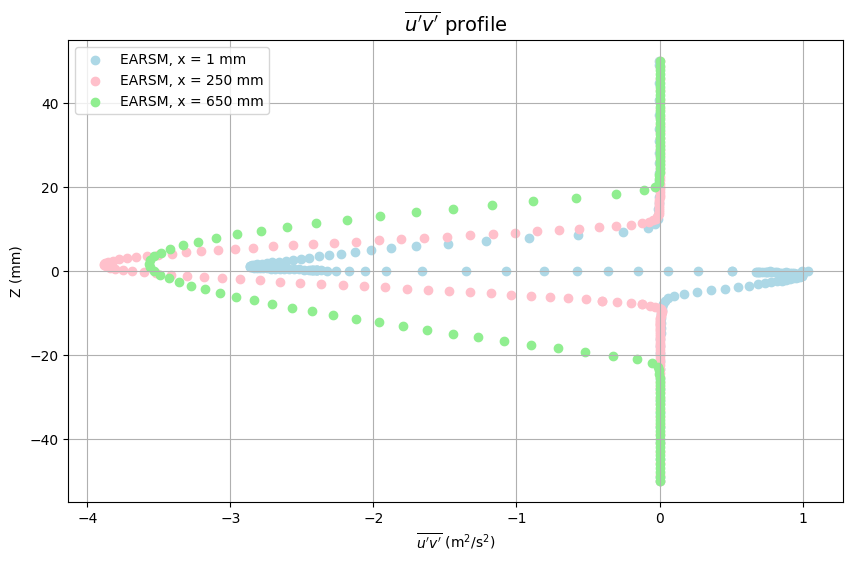

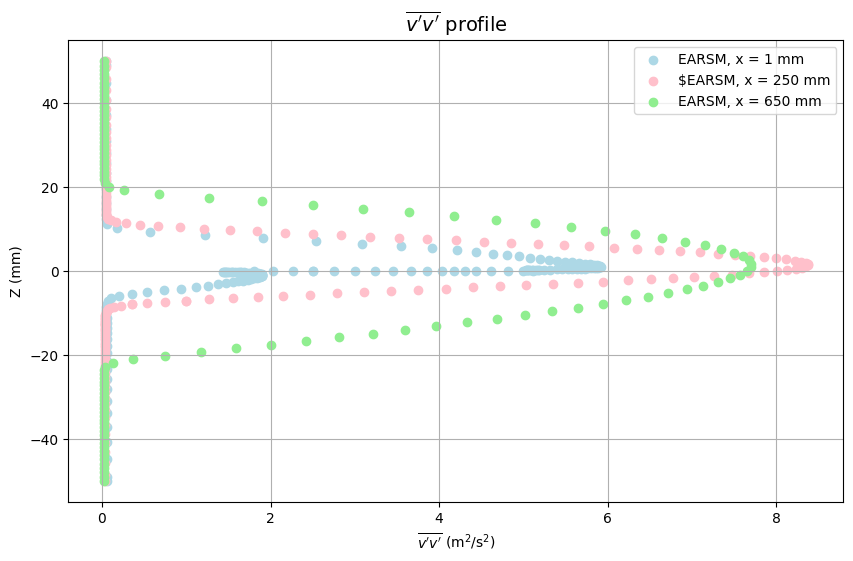

,earsm-uu-uu_x=1mm,earsm-uu-Z-Coordinate_x=1mm,earsm-uu-uu_x=200,earsm-uu-Z-Coordinate_x=200,earsm-uu-uu_x=650mm,earsm-uu-Z-Coordinate_x=650mm,earsm-uv-uv_x=1mm,earsm-uv-Z-Coordinate_x=1mm,earsm-uv-uv_x=200,earsm-uv-Z-Coordinate_x=200,...,earsm-vv-vv_x=200,earsm-vv-Z-Coordinate_x=200,earsm-vv-vv_x=650mm,earsm-vv-Z-Coordinate_x=650mm,earsm-vel-Velocity Magnitude_x=1mm,earsm-vel-Z-Coordinate_x=1mm,earsm-vel-Velocity Magnitude_x=200,earsm-vel-Z-Coordinate_x=200,earsm-vel-Velocity Magnitude_x=650mm,earsm-vel-Z-Coordinate_x=650mm
0,0.068891,-5.000000e-02,0.039155,-0.050000,0.026499,0.050000,0.001124,-5.000000e-02,0.000007,-0.050000,...,0.039465,-0.050000,0.026620,0.050000,22.30190,-5.000000e-02,22.2833,-0.050000,41.5278,0.050000
1,0.068943,-4.911060e-02,0.039157,-0.048484,0.026500,0.048943,0.001170,-4.911060e-02,0.000007,-0.048484,...,0.039467,-0.048484,0.026622,0.048943,22.30090,-4.911060e-02,22.2833,-0.048484,41.5278,0.048943
2,0.069251,-4.475600e-02,0.039161,-0.045717,0.026502,0.047898,0.001455,-4.475600e-02,0.000005,-0.045717,...,0.039475,-0.045717,0.026623,0.047898,22.29480,-4.475600e-02,22.2833,-0.045717,41.5278,0.047898
3,0.069581,-4.078930e-02,0.039165,-0.043173,0.026503,0.046869,0.001768,-4.078930e-02,0.000003,-0.043173,...,0.039480,-0.043173,0.026625,0.046869,22.28800,-4.078930e-02,22.2832,-0.043173,41.5278,0.046869
4,0.069936,-3.717600e-02,0.039170,-0.040832,0.026505,0.045854,0.002119,-3.717600e-02,0.000001,-0.040832,...,0.039488,-0.040832,0.026627,0.045854,22.28040,-3.717600e-02,22.2832,-0.040832,41.5278,0.045854
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,1.163740,-3.056320e-18,NaN,NaN,NaN,NaN,-0.357033,-3.056320e-18,NaN,NaN,...,NaN,NaN,NaN,NaN,3.65790,-3.056320e-18,NaN,NaN,NaN,NaN
160,1.011850,-1.228280e-05,NaN,NaN,NaN,NaN,-0.147805,-1.228280e-05,NaN,NaN,...,NaN,NaN,NaN,NaN,3.63394,-1.228280e-05,NaN,NaN,NaN,NaN
161,0.921232,-2.462110e-05,NaN,NaN,NaN,NaN,0.057957,-2.462110e-05,NaN,NaN,...,NaN,NaN,NaN,NaN,3.63378,-2.462110e-05,NaN,NaN,NaN,NaN
162,0.886497,-3.707160e-05,NaN,NaN,NaN,NaN,0.266770,-3.707160e-05,NaN,NaN,...,NaN,NaN,NaN,NaN,3.66136,-3.707160e-05,NaN,NaN,NaN,NaN


In [11]:
import matplotlib
import pandas as pd
import re
import matplotlib.pyplot as plt

with open("exercise10/earsm-z-over-uu.xy", "r") as f:
    content = f.read()

# Extract labels
labels_match = re.search(r'\(labels\s+"([^"]+)"\s+"([^"]+)"\)', content)
if labels_match:
    label1, label2 = labels_match.groups()
else:
    raise ValueError("Could not find labels.")

# Extract each data block with its key/label
blocks = re.findall(
    r'\(xy/key/label\s+"([^"]+)"\)\s*((?:-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s+-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s*\n?)+)',
    content
)

dfs = []
for key, data_block in blocks:
    # Convert string block to list of [x, y]
    data = [
        list(map(float, line.strip().split()))
        for line in data_block.strip().splitlines()
        if line.strip()
    ]
    df = pd.DataFrame(data, columns=[f"earsm-uu-{label1}_{key}", f"earsm-uu-{label2}_{key}"])
    dfs.append(df)



# Combine into one dataframe, aligning rows
earsm_uu = pd.concat(dfs, axis=1)

# Show or save
earsm_uu

import pandas as pd
import re

with open("exercise10/earsm-z-over-uv.xy", "r") as f:
    content = f.read()

# Extract labels
labels_match = re.search(r'\(labels\s+"([^"]+)"\s+"([^"]+)"\)', content)
if labels_match:
    label1, label2 = labels_match.groups()
else:
    raise ValueError("Could not find labels.")

# Extract each data block with its key/label
blocks = re.findall(
    r'\(xy/key/label\s+"([^"]+)"\)\s*((?:-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s+-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s*\n?)+)',
    content
)

dfs = []
for key, data_block in blocks:
    # Convert string block to list of [x, y]
    data = [
        list(map(float, line.strip().split()))
        for line in data_block.strip().splitlines()
        if line.strip()
    ]
    df = pd.DataFrame(data, columns=[f"earsm-uv-{label1}_{key}", f"earsm-uv-{label2}_{key}"])
    dfs.append(df)


earsm_uv = pd.concat(dfs, axis=1)
earsm_uv

import pandas as pd
import re

with open("exercise10/earsm-z-over-vv.xy", "r") as f:
    content = f.read()

# Extract labels
labels_match = re.search(r'\(labels\s+"([^"]+)"\s+"([^"]+)"\)', content)
if labels_match:
    label1, label2 = labels_match.groups()
else:
    raise ValueError("Could not find labels.")

# Extract each data block with its key/label
blocks = re.findall(
    r'\(xy/key/label\s+"([^"]+)"\)\s*((?:-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s+-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s*\n?)+)',
    content
)

dfs = []
for key, data_block in blocks:
    # Convert string block to list of [x, y]
    data = [
        list(map(float, line.strip().split()))
        for line in data_block.strip().splitlines()
        if line.strip()
    ]
    df = pd.DataFrame(data, columns=[f"earsm-vv-{label1}_{key}", f"earsm-vv-{label2}_{key}"])
    dfs.append(df)


earsm_vv = pd.concat(dfs, axis=1)
earsm_vv.columns

with open("exercise10/earsm-z-over-velocity-magnitude.xy", "r") as f:
    content = f.read()

# Extract labels
labels_match = re.search(r'\(labels\s+"([^"]+)"\s+"([^"]+)"\)', content)
if labels_match:
    label1, label2 = labels_match.groups()
else:
    raise ValueError("Could not find labels.")

# Extract each data block with its key/label
blocks = re.findall(
    r'\(xy/key/label\s+"([^"]+)"\)\s*((?:-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s+-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s*\n?)+)',
    content
)

dfs = []
for key, data_block in blocks:
    # Convert string block to list of [x, y]
    data = [
        list(map(float, line.strip().split()))
        for line in data_block.strip().splitlines()
        if line.strip()
    ]
    df = pd.DataFrame(data, columns=[f"earsm-vel-{label1}_{key}", f"earsm-vel-{label2}_{key}"])
    dfs.append(df)


earsm_u = pd.concat(dfs, axis=1)

earsm = pd.concat([earsm_uu, earsm_uv, earsm_vv, earsm_u], axis=1)
earsm.columns

plt.figure(figsize=(10, 6))
plt.scatter(earsm['earsm-vel-Velocity Magnitude_x=1mm'], earsm['earsm-vel-Z-Coordinate_x=1mm']*1000,  label=r'EARSM, x = 1 mm', color='lightblue')
plt.scatter(earsm['earsm-vel-Velocity Magnitude_x=200'], earsm['earsm-vel-Z-Coordinate_x=200']*1000,  label=r'EARSM, x = 250 mm', color='pink')
plt.scatter(earsm['earsm-vel-Velocity Magnitude_x=650mm'], earsm['earsm-vel-Z-Coordinate_x=650mm']*1000,  label=r'EARSM, x = 650 mm', color='lightgreen')

plt.xlabel('U (m/s)')
plt.title('Velocity Profile')
plt.ylabel('Z (mm)')    
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(earsm['earsm-uu-uu_x=1mm'], earsm['earsm-uu-Z-Coordinate_x=1mm']*1000,  label=r'EARSM, x = 1 mm', color='lightblue')
plt.scatter(earsm['earsm-uu-uu_x=200'], earsm['earsm-uu-Z-Coordinate_x=200']*1000,  label=r'EARSM, x = 250 mm', color='pink')
plt.scatter(earsm['earsm-uu-uu_x=650mm'], earsm['earsm-uu-Z-Coordinate_x=650mm']*1000,  label=r'EARSM, x = 650 mm', color='lightgreen')
plt.xlabel(r"$\overline{u'u'}$ (m$^2$/s$^2$)")
plt.ylabel('Z (mm)')        
plt.title(r"$\overline{u'u'}$ profile", fontsize=14)
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(earsm['earsm-uv-uv_x=1mm'], earsm['earsm-uv-Z-Coordinate_x=1mm']*1000,  label=r'EARSM, x = 1 mm', color='lightblue')
plt.scatter(earsm['earsm-uv-uv_x=200'], earsm['earsm-uv-Z-Coordinate_x=200']*1000,  label=r'EARSM, x = 250 mm', color='pink')
plt.scatter(earsm['earsm-uv-uv_x=650mm'], earsm['earsm-uv-Z-Coordinate_x=650mm']*1000,  label=r'EARSM, x = 650 mm', color='lightgreen')
plt.xlabel(r"$\overline{u'v'}$ (m$^2$/s$^2$)")
plt.ylabel('Z (mm)')        
plt.title(r"$\overline{u'v'}$ profile", fontsize=14)
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(earsm['earsm-vv-vv_x=1mm'], earsm['earsm-vv-Z-Coordinate_x=1mm']*1000,  label=r'EARSM, x = 1 mm', color='lightblue')
plt.scatter(earsm['earsm-vv-vv_x=200'], earsm['earsm-vv-Z-Coordinate_x=200']*1000,  label=r'$EARSM, x = 250 mm', color='pink')
plt.scatter(earsm['earsm-vv-vv_x=650mm'], earsm['earsm-vv-Z-Coordinate_x=650mm']*1000,  label=r'EARSM, x = 650 mm', color='lightgreen')
plt.xlabel(r"$\overline{v'v'}$ (m$^2$/s$^2$)")
plt.ylabel('Z (mm)')        
plt.title(r"$\overline{v'v'}$ profile", fontsize=14)
plt.legend()
plt.grid()
plt.show()


earsm

In [24]:
sa.columns


Index(['sa-uu-Turbulent Viscosity_x=1mm', 'sa-uu-Z-Coordinate_x=1mm',
       'sa-uu-Turbulent Viscosity_x=200', 'sa-uu-Z-Coordinate_x=200',
       'sa-uu-Turbulent Viscosity_x=650mm', 'sa-uu-Z-Coordinate_x=650mm',
       'sa-vel-Velocity Magnitude_x=1mm', 'sa-vel-Z-Coordinate_x=1mm',
       'sa-vel-Velocity Magnitude_x=200', 'sa-vel-Z-Coordinate_x=200',
       'sa-vel-Velocity Magnitude_x=650mm', 'sa-vel-Z-Coordinate_x=650mm'],
      dtype='object')

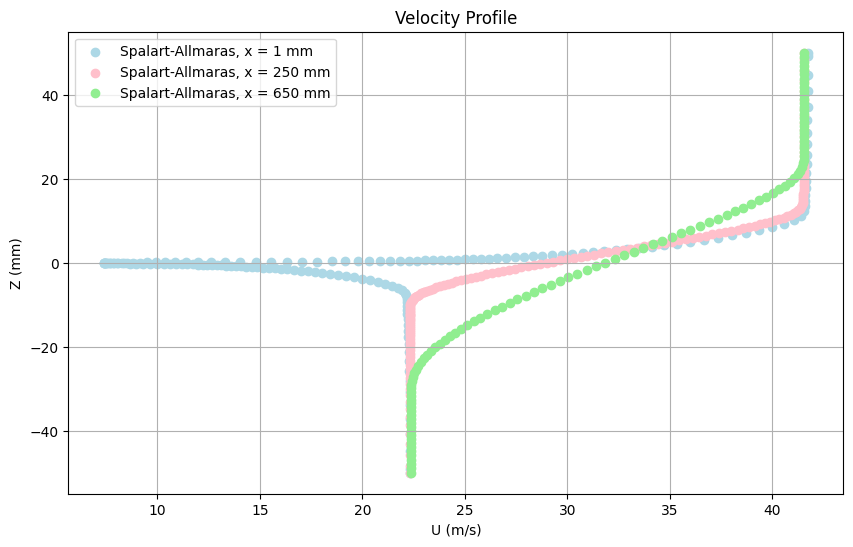

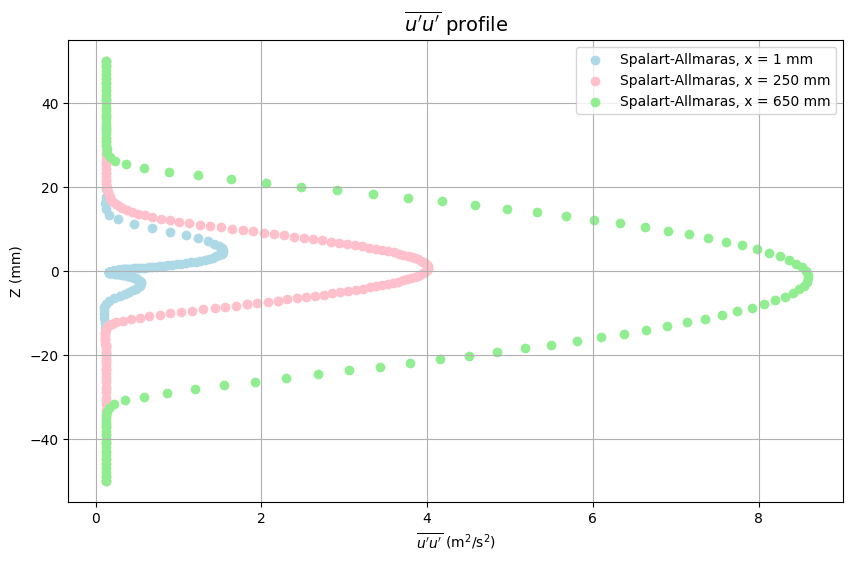

,sa-uu-Turbulent Viscosity_x=1mm,sa-uu-Z-Coordinate_x=1mm,sa-uu-Turbulent Viscosity_x=200,sa-uu-Z-Coordinate_x=200,sa-uu-Turbulent Viscosity_x=650mm,sa-uu-Z-Coordinate_x=650mm,sa-vel-Velocity Magnitude_x=1mm,sa-vel-Z-Coordinate_x=1mm,sa-vel-Velocity Magnitude_x=200,sa-vel-Z-Coordinate_x=200,sa-vel-Velocity Magnitude_x=650mm,sa-vel-Z-Coordinate_x=650mm
0,0.000130,-5.000000e-02,0.000130,-0.050000,0.00013,0.050000,22.34810,-5.000000e-02,22.3205,-0.050000,41.5352,0.050000
1,0.000130,-4.911060e-02,0.000130,-0.048484,0.00013,0.048943,22.34710,-4.911060e-02,22.3205,-0.048484,41.5352,0.048943
2,0.000130,-4.475600e-02,0.000130,-0.045717,0.00013,0.047898,22.34090,-4.475600e-02,22.3205,-0.045717,41.5352,0.047898
3,0.000130,-4.078930e-02,0.000130,-0.043173,0.00013,0.046869,22.33400,-4.078930e-02,22.3205,-0.043173,41.5351,0.046869
4,0.000129,-3.717600e-02,0.000129,-0.040832,0.00013,0.045854,22.32630,-3.717600e-02,22.3206,-0.040832,41.5351,0.045854
...,...,...,...,...,...,...,...,...,...,...,...,...
159,0.000236,-3.056320e-18,NaN,NaN,NaN,NaN,8.02720,-3.056320e-18,NaN,NaN,NaN,NaN
160,0.000231,-1.228280e-05,NaN,NaN,NaN,NaN,7.83398,-1.228280e-05,NaN,NaN,NaN,NaN
161,0.000226,-2.462110e-05,NaN,NaN,NaN,NaN,7.67461,-2.462110e-05,NaN,NaN,NaN,NaN
162,0.000221,-3.707160e-05,NaN,NaN,NaN,NaN,7.54928,-3.707160e-05,NaN,NaN,NaN,NaN


In [33]:
import matplotlib
import pandas as pd
import re
import matplotlib.pyplot as plt

with open("exercise10/sa-z-over-eddy-viscosity", "r") as f:
    content = f.read()

# Extract labels
labels_match = re.search(r'\(labels\s+"([^"]+)"\s+"([^"]+)"\)', content)
if labels_match:
    label1, label2 = labels_match.groups()
else:
    raise ValueError("Could not find labels.")

# Extract each data block with its key/label
blocks = re.findall(
    r'\(xy/key/label\s+"([^"]+)"\)\s*((?:-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s+-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s*\n?)+)',
    content
)

dfs = []
for key, data_block in blocks:
    # Convert string block to list of [x, y]
    data = [
        list(map(float, line.strip().split()))
        for line in data_block.strip().splitlines()
        if line.strip()
    ]
    df = pd.DataFrame(data, columns=[f"sa-uu-{label1}_{key}", f"sa-uu-{label2}_{key}"])
    dfs.append(df)



# Combine into one dataframe, aligning rows
sa_uu = pd.concat(dfs, axis=1)

# Show or save
sa_uu.columns


with open("exercise10/sa-z-over-velocity-magnitude.xy", "r") as f:
    content = f.read()

# Extract labels
labels_match = re.search(r'\(labels\s+"([^"]+)"\s+"([^"]+)"\)', content)
if labels_match:
    label1, label2 = labels_match.groups()
else:
    raise ValueError("Could not find labels.")

# Extract each data block with its key/label
blocks = re.findall(
    r'\(xy/key/label\s+"([^"]+)"\)\s*((?:-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s+-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s*\n?)+)',
    content
)

dfs = []
for key, data_block in blocks:
    # Convert string block to list of [x, y]
    data = [
        list(map(float, line.strip().split()))
        for line in data_block.strip().splitlines()
        if line.strip()
    ]
    df = pd.DataFrame(data, columns=[f"sa-vel-{label1}_{key}", f"sa-vel-{label2}_{key}"])
    dfs.append(df)


sa_u = pd.concat(dfs, axis=1)

sa = pd.concat([sa_uu, sa_u], axis=1)
sa.columns

plt.figure(figsize=(10, 6))
plt.scatter(sa['sa-vel-Velocity Magnitude_x=1mm'], sa['sa-vel-Z-Coordinate_x=1mm']*1000,  label=r'Spalart-Allmaras, x = 1 mm', color='lightblue')
plt.scatter(sa['sa-vel-Velocity Magnitude_x=200'], sa['sa-vel-Z-Coordinate_x=200']*1000,  label=r'Spalart-Allmaras, x = 250 mm', color='pink')
plt.scatter(sa['sa-vel-Velocity Magnitude_x=650mm'], sa['sa-vel-Z-Coordinate_x=650mm']*1000,  label=r'Spalart-Allmaras, x = 650 mm', color='lightgreen')

plt.xlabel('U (m/s)')
plt.title('Velocity Profile')
plt.ylabel('Z (mm)')    
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(sa['sa-uu-Turbulent Viscosity_x=1mm']*1000, sa['sa-uu-Z-Coordinate_x=1mm']*1000,  label=r'Spalart-Allmaras, x = 1 mm', color='lightblue')
plt.scatter(sa['sa-uu-Turbulent Viscosity_x=200']*1000, sa['sa-uu-Z-Coordinate_x=200']*1000,  label=r'Spalart-Allmaras, x = 250 mm', color='pink')
plt.scatter(sa['sa-uu-Turbulent Viscosity_x=650mm']*1000, sa['sa-uu-Z-Coordinate_x=650mm']*1000,  label=r'Spalart-Allmaras, x = 650 mm', color='lightgreen')
plt.xlabel(r"$\overline{u'u'}$ (m$^2$/s$^2$)")
plt.ylabel('Z (mm)')        
plt.title(r"$\overline{u'u'}$ profile", fontsize=14)
plt.legend()
plt.grid()
plt.show()
sa

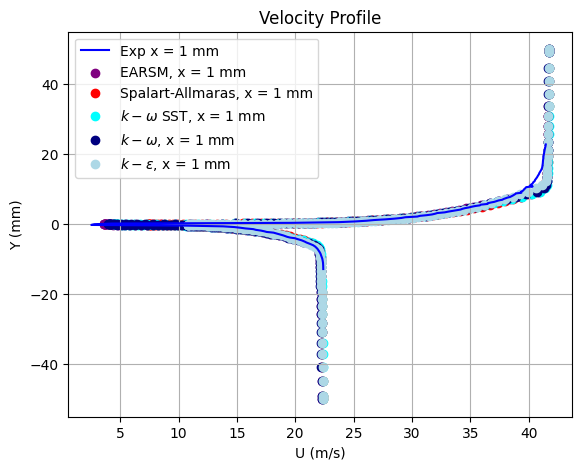

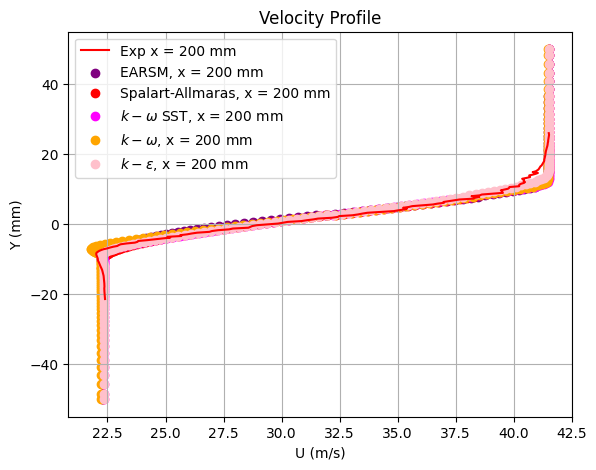

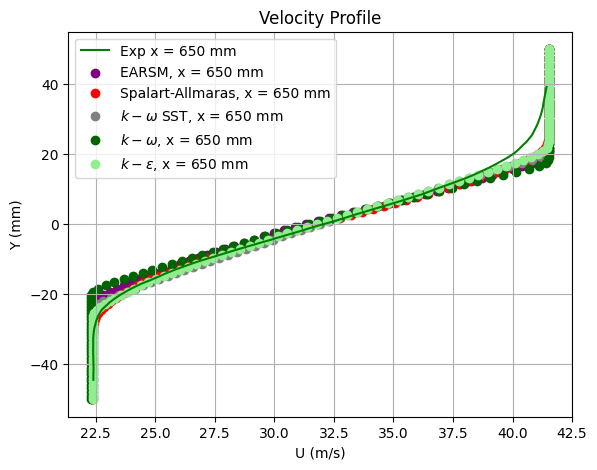

In [28]:
plt.figure(figsize=(6.5, 5))
plt.plot(df_nasa1['U(m/s)_x1'], df_nasa1['Y(mm)_x1'],  label=r'Exp x = 1 mm', color='blue')
plt.scatter(earsm['earsm-vel-Velocity Magnitude_x=1mm'], earsm['earsm-vel-Z-Coordinate_x=1mm']*1000,  label=r'EARSM, x = 1 mm', color='purple')
plt.scatter(sa['sa-vel-Velocity Magnitude_x=1mm'], sa['sa-vel-Z-Coordinate_x=1mm']*1000,  label=r'Spalart-Allmaras, x = 1 mm', color='red')

plt.scatter(ko_sst['ko-sst-vel-Velocity Magnitude_x=1mm'], ko_sst['ko-sst-vel-Z-Coordinate_x=1mm']*1000,  label=r'$k-\omega$ SST, x = 1 mm', color='cyan')
plt.scatter(ko['ko-vel-Velocity Magnitude_x=1mm'], ko['ko-vel-Z-Coordinate_x=1mm']*1000,  label=r'$k-\omega$, x = 1 mm', color='navy')
plt.scatter(ke['ke-vel-Velocity Magnitude_x=1mm'], ke['ke-vel-Z-Coordinate_x=1mm']*1000,  label=r'$k-\varepsilon$, x = 1 mm', color='lightblue')


plt.xlabel('U (m/s)')
plt.title('Velocity Profile')
plt.ylabel('Y (mm)')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(6.5, 5))

plt.plot(df_nasa1['U(m/s)_x200'], df_nasa1['Y(mm)_x200'],  label=r'Exp x = 200 mm', color='red')
plt.scatter(earsm['earsm-vel-Velocity Magnitude_x=200'], earsm['earsm-vel-Z-Coordinate_x=200']*1000,  label=r'EARSM, x = 200 mm', color='purple')
plt.scatter(sa['sa-vel-Velocity Magnitude_x=200'], sa['sa-vel-Z-Coordinate_x=200']*1000,  label=r'Spalart-Allmaras, x = 200 mm', color='red')

plt.scatter(ko_sst['ko-sst-vel-Velocity Magnitude_x=200'], ko_sst['ko-sst-vel-Z-Coordinate_x=200']*1000,  label=r'$k-\omega$ SST, x = 200 mm', color='magenta')
plt.scatter(ko['ko-vel-Velocity Magnitude_x=200'], ko['ko-vel-Z-Coordinate_x=200']*1000,  label=r'$k-\omega$, x = 200 mm', color='orange')
plt.scatter(ke['ke-vel-Velocity Magnitude_x=200'], ke['ke-vel-Z-Coordinate_x=200']*1000,  label=r'$k-\varepsilon$, x = 200 mm', color='pink')


plt.xlabel('U (m/s)')
plt.title('Velocity Profile')
plt.ylabel('Y (mm)')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(6.5, 5))

plt.plot(df_nasa1['U(m/s)_x650'], df_nasa1['Y(mm)_x650'],  label=r'Exp x = 650 mm', color='green')
plt.scatter(earsm['earsm-vel-Velocity Magnitude_x=650mm'], earsm['earsm-vel-Z-Coordinate_x=650mm']*1000,  label=r'EARSM, x = 650 mm', color='purple')
plt.scatter(sa['sa-vel-Velocity Magnitude_x=650mm'], sa['sa-vel-Z-Coordinate_x=650mm']*1000,  label=r'Spalart-Allmaras, x = 650 mm', color='red')

plt.scatter(ko_sst['ko-sst-vel-Velocity Magnitude_x=650mm'], ko_sst['ko-sst-vel-Z-Coordinate_x=650mm']*1000,  label=r'$k-\omega$ SST, x = 650 mm', color='grey')   
plt.scatter(ko['ko-vel-Velocity Magnitude_x=650mm'], ko['ko-vel-Z-Coordinate_x=650mm']*1000,  label=r'$k-\omega$, x = 650 mm', color='darkgreen')
plt.scatter(ke['ke-vel-Velocity Magnitude_x=650mm'], ke['ke-vel-Z-Coordinate_x=650mm']*1000,  label=r'$k-\varepsilon$, x = 650 mm', color='lightgreen')

plt.xlabel('U (m/s)')
plt.title('Velocity Profile')
plt.ylabel('Y (mm)')
plt.legend()
plt.grid()
plt.show()



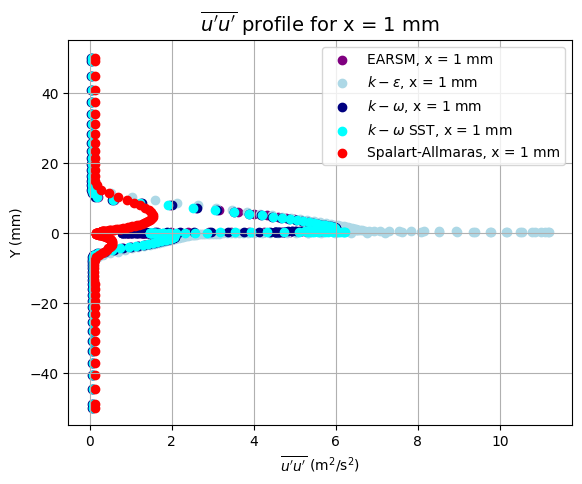

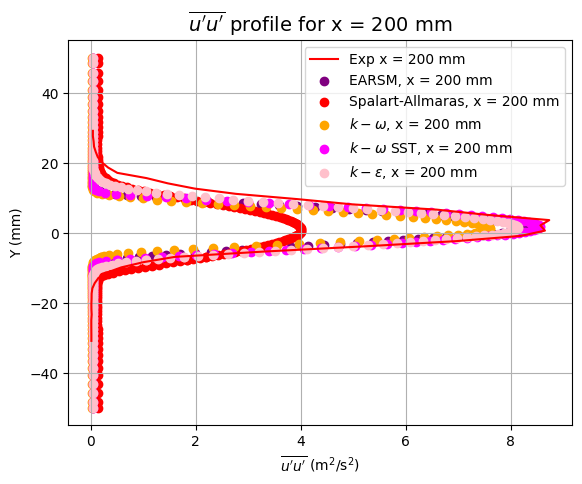

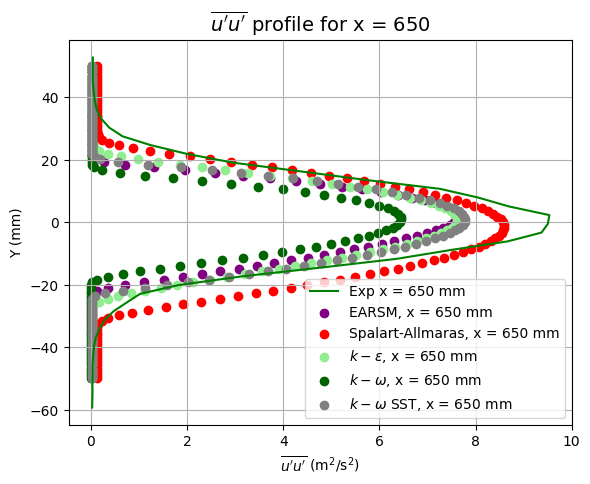

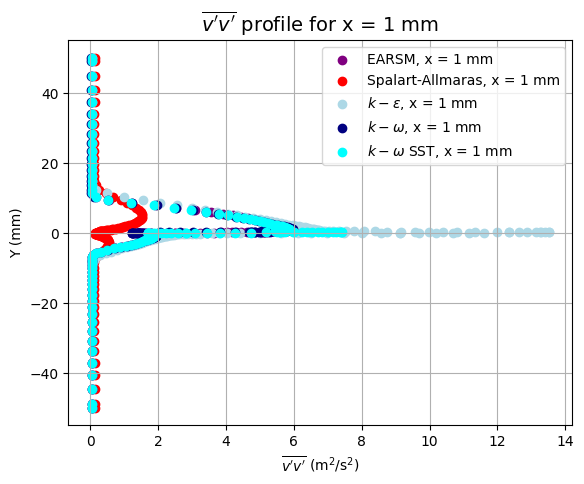

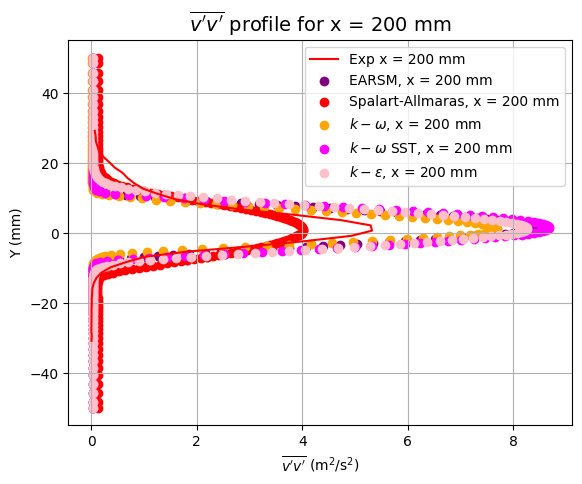

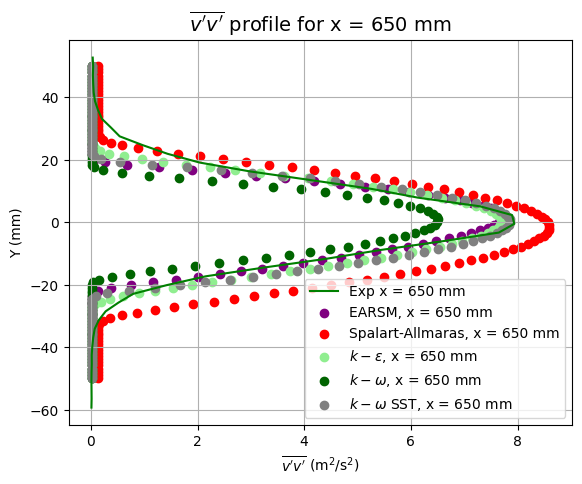

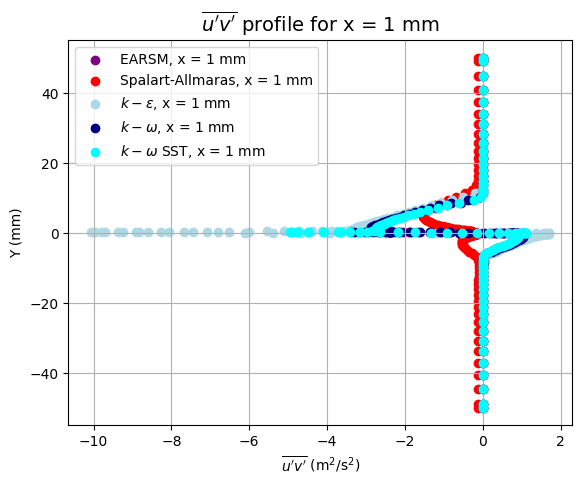

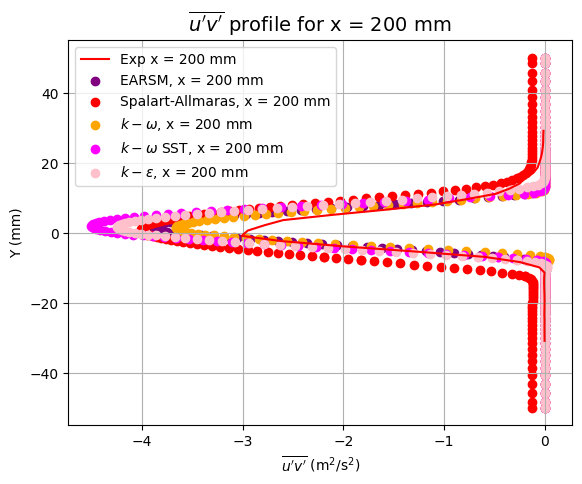

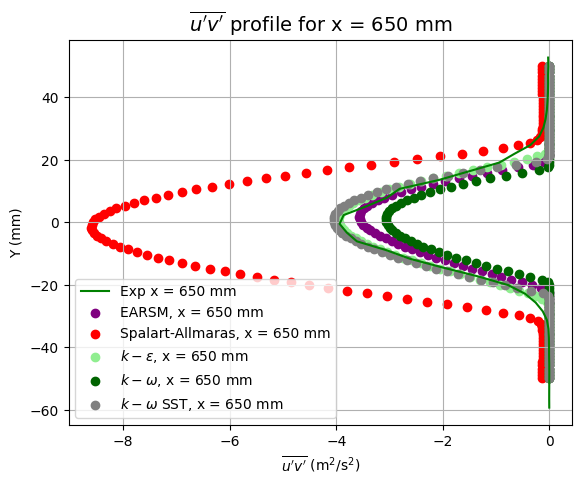

In [38]:
#uu profile for x=1mm
plt.figure(figsize=(6.5, 5))

plt.scatter(earsm['earsm-uu-uu_x=1mm'], earsm['earsm-uu-Z-Coordinate_x=1mm']*1000,  label=r'EARSM, x = 1 mm', color='purple')
plt.scatter(ke['ke-uu-uu_x=1mm'], ke['ke-uu-Z-Coordinate_x=1mm']*1000,  label=r'$k-\varepsilon$, x = 1 mm', color='lightblue')
plt.scatter(ko['ko-uu-uu_x=1mm'], ko['ko-uu-Z-Coordinate_x=1mm']*1000,  label=r'$k-\omega$, x = 1 mm', color='navy')
plt.scatter(ko_sst['ko-sst-uu-uu_x=1mm'], ko_sst['ko-sst-uu-Z-Coordinate_x=1mm']*1000,  label=r'$k-\omega$ SST, x = 1 mm', color='cyan')
plt.scatter(sa['sa-uu-Turbulent Viscosity_x=1mm']*1000, sa['sa-uu-Z-Coordinate_x=1mm']*1000,  label=r'Spalart-Allmaras, x = 1 mm', color='red')

plt.title(r"$\overline{u'u'}$ profile for x = 1 mm", fontsize=14)
plt.xlabel(r"$\overline{u'u'}$ (m$^2$/s$^2$)")
plt.ylabel('Y (mm)')
plt.legend()
plt.grid()
plt.show()


#uu profile for x=200mm
plt.figure(figsize=(6.5, 5))
plt.plot( df_nasa_axis2["u'u'(m**2/s**2)_x200"],  df_nasa_axis2['Y(mm)_x200'], label=r'Exp x = 200 mm', color='red')
plt.scatter(earsm['earsm-uu-uu_x=200'], earsm['earsm-uu-Z-Coordinate_x=200']*1000,  label=r'EARSM, x = 200 mm', color='purple')
plt.scatter(sa['sa-uu-Turbulent Viscosity_x=200']*1000, sa['sa-uu-Z-Coordinate_x=200']*1000,  label=r'Spalart-Allmaras, x = 200 mm', color='red')

plt.scatter(ko['ko-uu-uu_x=200'], ko['ko-uu-Z-Coordinate_x=200']*1000,  label=r'$k-\omega$, x = 200 mm', color='orange')
plt.scatter(ko_sst['ko-sst-uu-uu_x=200'], ko_sst['ko-sst-uu-Z-Coordinate_x=200']*1000,  label=r'$k-\omega$ SST, x = 200 mm', color='magenta')
plt.scatter(ke['ke-uu-uu_x=200'], ke['ke-uu-Z-Coordinate_x=200']*1000,  label=r'$k-\varepsilon$, x = 200 mm', color='pink')

plt.title(r"$\overline{u'u'}$ profile for x = 200 mm", fontsize=14)
plt.xlabel(r"$\overline{u'u'}$ (m$^2$/s$^2$)")
plt.ylabel('Y (mm)')
plt.legend()
plt.grid()
plt.show()

#uu profile for x=650mm
plt.figure(figsize=(6.5, 5))
plt.plot( df_nasa_axis2["u'u'(m**2/s**2)_x650"],  df_nasa_axis2['Y(mm)_x650'], label=r'Exp x = 650 mm', color='green')
plt.scatter(earsm['earsm-uu-uu_x=650mm'], earsm['earsm-uu-Z-Coordinate_x=650mm']*1000,  label=r'EARSM, x = 650 mm', color='purple')
plt.scatter(sa['sa-uu-Turbulent Viscosity_x=650mm']*1000, sa['sa-uu-Z-Coordinate_x=650mm']*1000,  label=r'Spalart-Allmaras, x = 650 mm', color='red')

plt.scatter(ke['ke-uu-uu_x=650mm'], ke['ke-uu-Z-Coordinate_x=650mm']*1000,  label=r'$k-\varepsilon$, x = 650 mm', color='lightgreen')
plt.scatter(ko['ko-uu-uu_x=650mm'], ko['ko-uu-Z-Coordinate_x=650mm']*1000,  label=r'$k-\omega$, x = 650 mm', color='darkgreen')
plt.scatter(ko_sst['ko-sst-uu-uu_x=650mm'], ko_sst['ko-sst-uu-Z-Coordinate_x=650mm']*1000,  label=r'$k-\omega$ SST, x = 650 mm', color='grey')

plt.title(r"$\overline{u'u'}$ profile for x = 650", fontsize=14)
plt.xlabel(r"$\overline{u'u'}$ (m$^2$/s$^2$)")
plt.ylabel('Y (mm)')
plt.legend()
plt.grid()
plt.show()


#vv profile for x=1mm
plt.figure(figsize=(6.5, 5))

plt.scatter(earsm['earsm-vv-vv_x=1mm'], earsm['earsm-vv-Z-Coordinate_x=1mm']*1000,  label=r'EARSM, x = 1 mm', color='purple')
plt.scatter(sa['sa-uu-Turbulent Viscosity_x=1mm']*1000, sa['sa-uu-Z-Coordinate_x=1mm']*1000,  label=r'Spalart-Allmaras, x = 1 mm', color='red')

plt.scatter(ke['ke-vv-vv_x=1mm'], ke['ke-vv-Z-Coordinate_x=1mm']*1000,  label=r'$k-\varepsilon$, x = 1 mm', color='lightblue')
plt.scatter(ko['ko-vv-vv_x=1mm'], ko['ko-vv-Z-Coordinate_x=1mm']*1000,  label=r'$k-\omega$, x = 1 mm', color='navy')
plt.scatter(ko_sst['ko-sst-vv-vv_x=1mm'], ko_sst['ko-sst-vv-Z-Coordinate_x=1mm']*1000,  label=r'$k-\omega$ SST, x = 1 mm', color='cyan')

plt.title(r"$\overline{v'v'}$ profile for x = 1 mm", fontsize=14)
plt.xlabel(r"$\overline{v'v'}$ (m$^2$/s$^2$)")
plt.ylabel('Y (mm)')
plt.legend()
plt.grid()
plt.show()

#vv profile for x=200mm
plt.figure(figsize=(6.5, 5))
plt.plot( df_nasa_axis2["w'w'(m**2/s**2)_x200"],  df_nasa_axis2['Y(mm)_x200'], label=r'Exp x = 200 mm', color='red')
plt.scatter(earsm['earsm-vv-vv_x=200'], earsm['earsm-vv-Z-Coordinate_x=200']*1000,  label=r'EARSM, x = 200 mm', color='purple')
plt.scatter(sa['sa-uu-Turbulent Viscosity_x=200']*1000, sa['sa-uu-Z-Coordinate_x=200']*1000,  label=r'Spalart-Allmaras, x = 200 mm', color='red')
plt.scatter(ko['ko-vv-vv_x=200'], ko['ko-vv-Z-Coordinate_x=200']*1000,  label=r'$k-\omega$, x = 200 mm', color='orange')
plt.scatter(ko_sst['ko-sst-vv-vv_x=200'], ko_sst['ko-sst-vv-Z-Coordinate_x=200']*1000,  label=r'$k-\omega$ SST, x = 200 mm', color='magenta')
plt.scatter(ke['ke-vv-vv_x=200'], ke['ke-vv-Z-Coordinate_x=200']*1000,  label=r'$k-\varepsilon$, x = 200 mm', color='pink')

plt.title(r"$\overline{v'v'}$ profile for x = 200 mm", fontsize=14)
plt.xlabel(r"$\overline{v'v'}$ (m$^2$/s$^2$)")
plt.ylabel('Y (mm)')
plt.legend()
plt.grid()
plt.show()



#vv profile for x=650mm
plt.figure(figsize=(6.5, 5))
plt.plot( df_nasa_axis2["w'w'(m**2/s**2)_x650"],  df_nasa_axis2['Y(mm)_x650'], label=r'Exp x = 650 mm', color='green')
plt.scatter(earsm['earsm-vv-vv_x=650mm'], earsm['earsm-vv-Z-Coordinate_x=650mm']*1000,  label=r'EARSM, x = 650 mm', color='purple')
plt.scatter(sa['sa-uu-Turbulent Viscosity_x=650mm']*1000, sa['sa-uu-Z-Coordinate_x=650mm']*1000,  label=r'Spalart-Allmaras, x = 650 mm', color='red')
plt.scatter(ke['ke-vv-vv_x=650mm'], ke['ke-vv-Z-Coordinate_x=650mm']*1000,  label=r'$k-\varepsilon$, x = 650 mm', color='lightgreen')
plt.scatter(ko['ko-vv-vv_x=650mm'], ko['ko-vv-Z-Coordinate_x=650mm']*1000,  label=r'$k-\omega$, x = 650 mm', color='darkgreen')
plt.scatter(ko_sst['ko-sst-vv-vv_x=650mm'], ko_sst['ko-sst-vv-Z-Coordinate_x=650mm']*1000,  label=r'$k-\omega$ SST, x = 650 mm', color='grey')

plt.title(r"$\overline{v'v'}$ profile for x = 650 mm", fontsize=14)
plt.xlabel(r"$\overline{v'v'}$ (m$^2$/s$^2$)")
plt.ylabel('Y (mm)')
plt.legend()
plt.grid()
plt.show()

#uv profile for x=1mm
plt.figure(figsize=(6.5, 5))

plt.scatter(earsm['earsm-uv-uv_x=1mm'], earsm['earsm-uv-Z-Coordinate_x=1mm']*1000,  label=r'EARSM, x = 1 mm', color='purple')
plt.scatter(-sa['sa-uu-Turbulent Viscosity_x=1mm']*1000, sa['sa-uu-Z-Coordinate_x=1mm']*1000,  label=r'Spalart-Allmaras, x = 1 mm', color='red')
plt.scatter(ke['ke-uv-uv_x=1mm'], ke['ke-uv-Z-Coordinate_x=1mm']*1000,  label=r'$k-\varepsilon$, x = 1 mm', color='lightblue')
plt.scatter(ko['ko-uv-uv_x=1mm'], ko['ko-uv-Z-Coordinate_x=1mm']*1000,  label=r'$k-\omega$, x = 1 mm', color='navy')
plt.scatter(ko_sst['ko-sst-uv-uv_x=1mm'], ko_sst['ko-sst-uv-Z-Coordinate_x=1mm']*1000,  label=r'$k-\omega$ SST, x = 1 mm', color='cyan')

plt.title(r"$\overline{u'v'}$ profile for x = 1 mm", fontsize=14)
plt.xlabel(r"$\overline{u'v'}$ (m$^2$/s$^2$)")
plt.ylabel('Y (mm)')
plt.legend()
plt.grid()
plt.show()

#uv profile for x=200mm
plt.figure(figsize=(6.5, 5))
plt.plot( df_nasa_axis2["u'v'(m**2/s**2)_x200"],  df_nasa_axis2['Y(mm)_x200'], label=r'Exp x = 200 mm', color='red')
plt.scatter(earsm['earsm-uv-uv_x=200'], earsm['earsm-uv-Z-Coordinate_x=200']*1000,  label=r'EARSM, x = 200 mm', color='purple')  
plt.scatter(-sa['sa-uu-Turbulent Viscosity_x=200']*1000, sa['sa-uu-Z-Coordinate_x=200']*1000,  label=r'Spalart-Allmaras, x = 200 mm', color='red')
plt.scatter(ko['ko-uv-uv_x=200'], ko['ko-uv-Z-Coordinate_x=200']*1000,  label=r'$k-\omega$, x = 200 mm', color='orange')
plt.scatter(ko_sst['ko-sst-uv-uv_x=200'], ko_sst['ko-sst-uv-Z-Coordinate_x=200']*1000,  label=r'$k-\omega$ SST, x = 200 mm', color='magenta')
plt.scatter(ke['ke-uv-uv_x=200'], ke['ke-uv-Z-Coordinate_x=200']*1000,  label=r'$k-\varepsilon$, x = 200 mm', color='pink')

plt.title(r"$\overline{u'v'}$ profile for x = 200 mm", fontsize=14)
plt.xlabel(r"$\overline{u'v'}$ (m$^2$/s$^2$)")
plt.ylabel('Y (mm)')
plt.legend()
plt.grid()
plt.show()

#uv profile for x=650mm
plt.figure(figsize=(6.5, 5))
plt.plot( df_nasa_axis2["u'v'(m**2/s**2)_x650"],  df_nasa_axis2['Y(mm)_x650'], label=r'Exp x = 650 mm', color='green')

plt.scatter(earsm['earsm-uv-uv_x=650mm'], earsm['earsm-uv-Z-Coordinate_x=650mm']*1000,  label=r'EARSM, x = 650 mm', color='purple')
plt.scatter(-sa['sa-uu-Turbulent Viscosity_x=650mm']*1000, sa['sa-uu-Z-Coordinate_x=650mm']*1000,  label=r'Spalart-Allmaras, x = 650 mm', color='red')
plt.scatter(ke['ke-uv-uv_x=650mm'], ke['ke-uv-Z-Coordinate_x=650mm']*1000,  label=r'$k-\varepsilon$, x = 650 mm', color='lightgreen')
plt.scatter(ko['ko-uv-uv_x=650mm'], ko['ko-uv-Z-Coordinate_x=650mm']*1000,  label=r'$k-\omega$, x = 650 mm', color='darkgreen')
plt.scatter(ko_sst['ko-sst-uv-uv_x=650mm'], ko_sst['ko-sst-uv-Z-Coordinate_x=650mm']*1000,  label=r'$k-\omega$ SST, x = 650 mm', color='grey')

plt.title(r"$\overline{u'v'}$ profile for x = 650 mm", fontsize=14)
plt.xlabel(r"$\overline{u'v'}$ (m$^2$/s$^2$)")
plt.ylabel('Y (mm)')
plt.legend()
plt.grid()
plt.show()


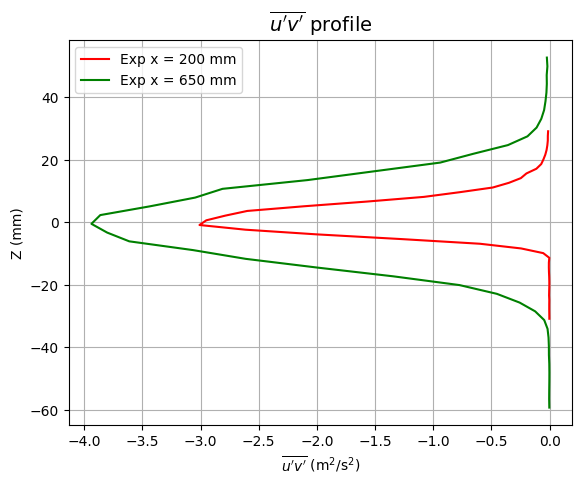

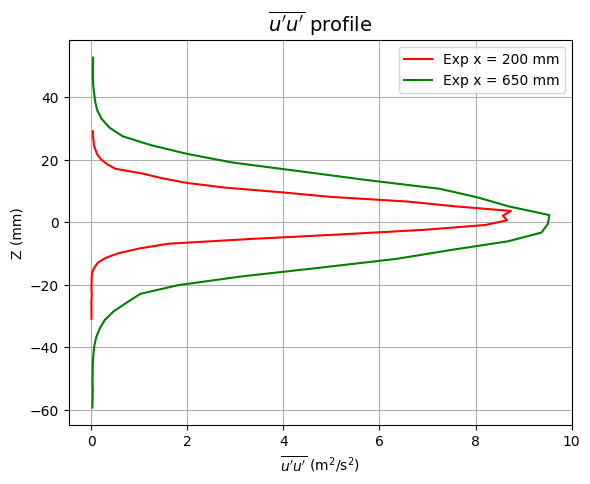

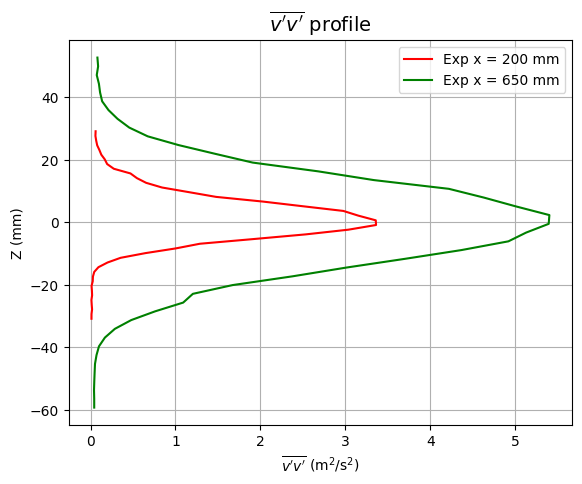

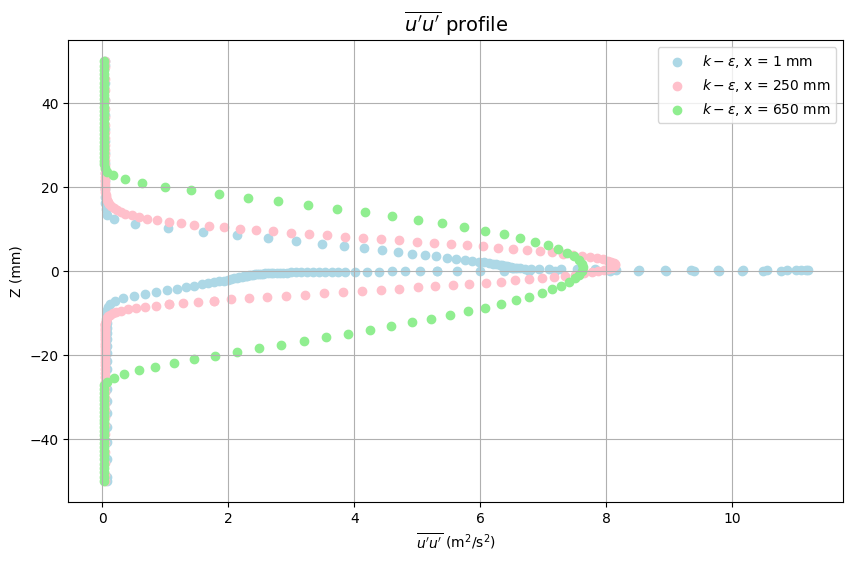

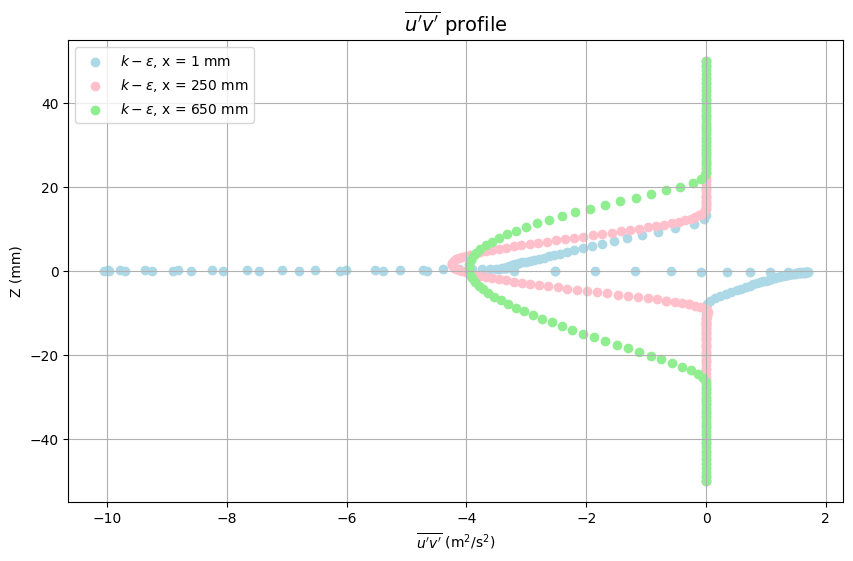

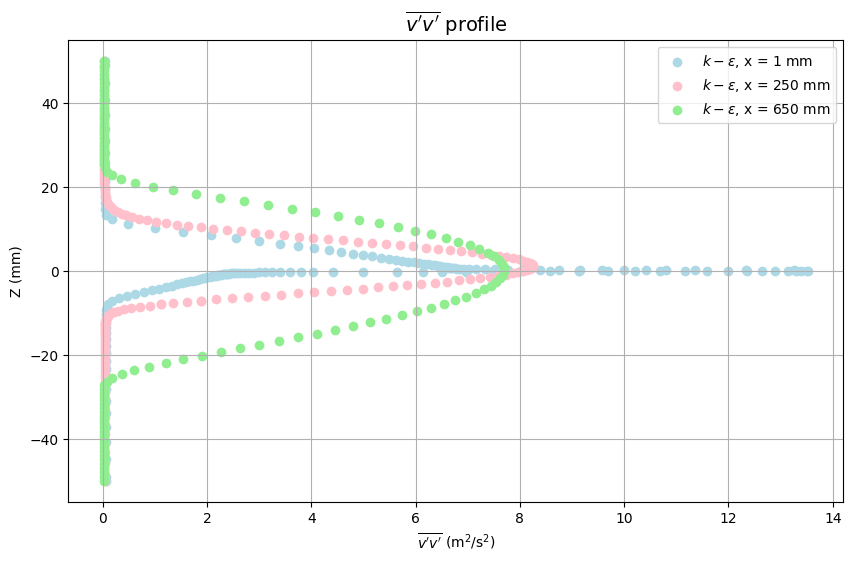

In [14]:

df_nasa_axis2 = read_txt_file(file2)

plt.figure(figsize=(6.5, 5))

plt.plot( df_nasa_axis2["u'v'(m**2/s**2)_x200"],  df_nasa_axis2['Y(mm)_x200'], label=r'Exp x = 200 mm', color='red')
plt.plot(df_nasa_axis2["u'v'(m**2/s**2)_x650"],df_nasa_axis2['Y(mm)_x650'],   label=r'Exp x = 650 mm', color='green')

plt.xlabel(r"$\overline{u'v'}$ (m$^2$/s$^2$)")
plt.ylabel('Z (mm)')
plt.title(r"$\overline{u'v'}$ profile", fontsize=14)

plt.legend()
plt.grid()
plt.show()


plt.figure(figsize=(6.5, 5))

plt.plot( df_nasa_axis2["u'u'(m**2/s**2)_x200"],  df_nasa_axis2['Y(mm)_x200'], label=r'Exp x = 200 mm', color='red')
plt.plot(df_nasa_axis2["u'u'(m**2/s**2)_x650"],df_nasa_axis2['Y(mm)_x650'],   label=r'Exp x = 650 mm', color='green')

plt.xlabel(r"$\overline{u'u'}$ (m$^2$/s$^2$)")
plt.ylabel('Z (mm)')
plt.title(r"$\overline{u'u'}$ profile", fontsize=14)

plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(6.5, 5))

plt.plot( df_nasa_axis2["v'v'(m**2/s**2)_x200"],  df_nasa_axis2['Y(mm)_x200'], label=r'Exp x = 200 mm', color='red')
plt.plot(df_nasa_axis2["v'v'(m**2/s**2)_x650"],df_nasa_axis2['Y(mm)_x650'],   label=r'Exp x = 650 mm', color='green')

plt.xlabel(r"$\overline{v'v'}$ (m$^2$/s$^2$)")
plt.ylabel('Z (mm)')
plt.title(r"$\overline{v'v'}$ profile", fontsize=14)

plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(ke['ke-uu-uu_x=1mm'], ke['ke-uu-Z-Coordinate_x=1mm']*1000,  label=r'$k-\varepsilon$, x = 1 mm', color='lightblue')
plt.scatter(ke['ke-uu-uu_x=200'], ke['ke-uu-Z-Coordinate_x=200']*1000,  label=r'$k-\varepsilon$, x = 250 mm', color='pink')
plt.scatter(ke['ke-uu-uu_x=650mm'], ke['ke-uu-Z-Coordinate_x=650mm']*1000,  label=r'$k-\varepsilon$, x = 650 mm', color='lightgreen')
plt.xlabel(r"$\overline{u'u'}$ (m$^2$/s$^2$)")
plt.ylabel('Z (mm)')        
plt.title(r"$\overline{u'u'}$ profile", fontsize=14)
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(ke['ke-uv-uv_x=1mm'], ke['ke-uv-Z-Coordinate_x=1mm']*1000,  label=r'$k-\varepsilon$, x = 1 mm', color='lightblue')
plt.scatter(ke['ke-uv-uv_x=200'], ke['ke-uv-Z-Coordinate_x=200']*1000,  label=r'$k-\varepsilon$, x = 250 mm', color='pink')
plt.scatter(ke['ke-uv-uv_x=650mm'], ke['ke-uv-Z-Coordinate_x=650mm']*1000,  label=r'$k-\varepsilon$, x = 650 mm', color='lightgreen')
plt.xlabel(r"$\overline{u'v'}$ (m$^2$/s$^2$)")
plt.ylabel('Z (mm)')        
plt.title(r"$\overline{u'v'}$ profile", fontsize=14)
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(ke['ke-vv-vv_x=1mm'], ke['ke-vv-Z-Coordinate_x=1mm']*1000,  label=r'$k-\varepsilon$, x = 1 mm', color='lightblue')
plt.scatter(ke['ke-vv-vv_x=200'], ke['ke-vv-Z-Coordinate_x=200']*1000,  label=r'$k-\varepsilon$, x = 250 mm', color='pink')
plt.scatter(ke['ke-vv-vv_x=650mm'], ke['ke-vv-Z-Coordinate_x=650mm']*1000,  label=r'$k-\varepsilon$, x = 650 mm', color='lightgreen')
plt.xlabel(r"$\overline{v'v'}$ (m$^2$/s$^2$)")
plt.ylabel('Z (mm)')        
plt.title(r"$\overline{v'v'}$ profile", fontsize=14)
plt.legend()
plt.grid()
plt.show()